# MIS 58900 — Group Assignment 1
## Airbnb Dallas: Superhost Status, Bookings and Revenue

**Dataset:** `airbnb_dallas.csv` — 48,711 rows x 111 columns.

**Important — this is panel data, not a list of listings.** Each row is **one property in one
Superhost evaluation period**, identified by `Airbnb Property ID` + `superhost_period_all`.
A single property appears in many rows. So any "average for Superhosts" below is an average
over *property-periods* unless we say otherwise.

Most columns have a `prev_` twin holding the same measure from the previous period
(`revenue` / `prev_revenue`, `booked_days` / `prev_booked_days`, ...). That is what makes the
before/after comparison in Question 7 possible within a single row.

All sixteen questions are answered below. Each has its own heading, the question as asked, one
code cell, and a written finding, so the question and its evidence stay together.

## Setup — load the data once

In [1]:
# Libraries: pandas for the data, matplotlib + seaborn for charts,
# scipy for the significance tests used in Q5 and Q7
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display settings so wide tables and charts print readably
pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

# Load once. Every question below reuses this dataframe.
# In Colab there is no local file, so fall back to an upload prompt.
try:
    df = pd.read_csv('airbnb_dallas.csv', low_memory=False)
except FileNotFoundError:
    from google.colab import files
    import io
    up = files.upload()                      # choose airbnb_dallas.csv
    df = pd.read_csv(io.BytesIO(up['airbnb_dallas.csv']), low_memory=False)

# Basic shape of the dataset and how many real properties it covers
print('Rows, columns:', df.shape)
print('Distinct properties :', df['Airbnb Property ID'].nunique())
print('Evaluation periods  :', int(df['superhost_period_all'].min()), 'to',
      int(df['superhost_period_all'].max()))
print()

# Superhost flag: confirm the two status columns agree before we rely on one of them
# .mean() on a True/False series gives the share that are True, so this is the
# fraction of rows where the flags match. 1.0 = they are fully redundant
agree = (df['Superhost'] == df['host_is_superhost_in_period']).mean()
print("'Superhost' agrees with 'host_is_superhost_in_period' on {:.1%} of rows".format(agree))
print(df['Superhost'].value_counts().rename({0.0: 'Non-Superhost', 1.0: 'Superhost'}))
print()

# Greyscale safety. The deliverable is a PDF read in print, where our two fills
# (#8C8C8C grey and #DD8452 orange) sit at almost the same luminance and become
# indistinguishable. Hatching the second group keeps every comparison legible
# without relying on colour at all.
def hatch_second(ax, hatch='//'):
    """Apply a hatch to the second group's boxes/bars on `ax`."""
    boxes = [p for p in ax.patches if hasattr(p, 'set_hatch')]
    for p in boxes[1::2] if len(boxes) > 2 else boxes[1:]:
        p.set_hatch(hatch)
        p.set_edgecolor('#333333')

# Readable group label used by every chart from here on.
# Built in a single concat rather than one insert at a time, which otherwise emits
# PerformanceWarning: DataFrame is highly fragmented -- and those warnings print into
# the graded PDF.
df = pd.concat([df, pd.DataFrame({
    'Superhost status': np.where(df['Superhost'] == 1, 'Superhost', 'Non-Superhost'),
    'booked_days_z': df['booked_days'].fillna(0),
    'revenue_z': df['revenue'].fillna(0),
    # True where we have positive evidence the property was on the market that period
    'on_market': ~(df['booked_days'].isna() & df['available_days'].isna()),
}, index=df.index)], axis=1)

# How missing values behave in this dataset 
# booked_days and revenue are null on the same rows. Those rows still have available_days,
# so they are property-periods that were listed but never booked - a real zero, not a
# recording failure. We report both readings rather than dropping them silently
# A boolean mask: True on every row where booked_days was not recorded
nb_null = df['booked_days'].isna()
print('Rows with null booked_days / revenue :', int(nb_null.sum()),
      '({:.1%} of all rows)'.format(nb_null.mean()))
print('  ... of those, rows that still have available_days recorded:',
      int(df.loc[nb_null, 'available_days'].notna().sum()))
print('  ... of those, rows with NO available_days either:',
      int(df.loc[nb_null, 'available_days'].isna().sum()))
print('  min recorded booked_days:', df['booked_days'].min(),
      '| min recorded revenue:', df['revenue'].min(),
      '| min recorded available_days:', df['available_days'].min())
print('  -> No column records a literal 0; 0 is coded as null throughout. So the 16,861 rows')
print('     are two different things, and we should not call them all "idle listed inventory":')
print('       9,550 have available_days  -> on the market, listed but never booked.')
print('       7,311 have neither         -> most likely off-market / blocked for the period.')
print('     We report the full zero-filled view AND the on-market-only view, and say which.')

print()
print('On-market frame (excludes the 7,311 off-market rows): {} rows'.format(int(df['on_market'].sum())))

Rows, columns: (48711, 111)
Distinct properties : 9599
Evaluation periods  : 5 to 20

'Superhost' agrees with 'host_is_superhost_in_period' on 100.0% of rows
Superhost
Non-Superhost    32791
Superhost        15920
Name: count, dtype: int64

Rows with null booked_days / revenue : 16861 (34.6% of all rows)
  ... of those, rows that still have available_days recorded: 9550
  ... of those, rows with NO available_days either: 7311
  min recorded booked_days: 1.0 | min recorded revenue: 10.0 | min recorded available_days: 1.0
  -> No column records a literal 0; 0 is coded as null throughout. So the 16,861 rows
     are two different things, and we should not call them all "idle listed inventory":
       9,550 have available_days  -> on the market, listed but never booked.
       7,311 have neither         -> most likely off-market / blocked for the period.
     We report the full zero-filled view AND the on-market-only view, and say which.

On-market frame (excludes the 7,311 off-market rows

---
# Question 1 — Range and IQR of Nightly Rate

> Calculate the range and interquartile range (IQR) of Nightly Rate for the dataset. What do
> these measures tell you about the spread and variability of nightly rates across different
> listings?

Approach: Report count, min, max, range, Q1, Q3, IQR and median. The pair matters more
than either number alone: the range is set by the two most extreme listings in the file, while
the IQR describes the middle half of the market and ignores the tails. We also list the five
highest and five lowest rates so we can judge whether the extremes are real listings or data
errors. No outliers are removed.

Nightly Rate (USD) — spread statistics
Count (non-null)     48711.00
Missing                  0.00
Minimum                  1.00
Maximum               1900.00
Range (max-min)       1899.00
Q1 (25th pct)           69.00
Median (50th pct)      107.50
Q3 (75th pct)          185.12
IQR (Q3-Q1)            116.12
Mean                   157.17
Std deviation          169.89

Rows used: 48711 of 48711 (null Nightly Rate: 0)

5 highest nightly rates
 Airbnb Property ID   Neighborhood    Listing Type  Bedrooms  Nightly Rate
         18054750.0 Central Dallas Entire home/apt       2.0        1900.0
         18054750.0 Central Dallas Entire home/apt       2.0        1900.0
         18054750.0 Central Dallas Entire home/apt       2.0        1900.0
         18054750.0 Central Dallas Entire home/apt       2.0        1900.0
         18054750.0 Central Dallas Entire home/apt       2.0        1900.0

5 lowest nightly rates
 Airbnb Property ID   Neighborhood    Listing Type  Bedrooms  Nightly Rate
       

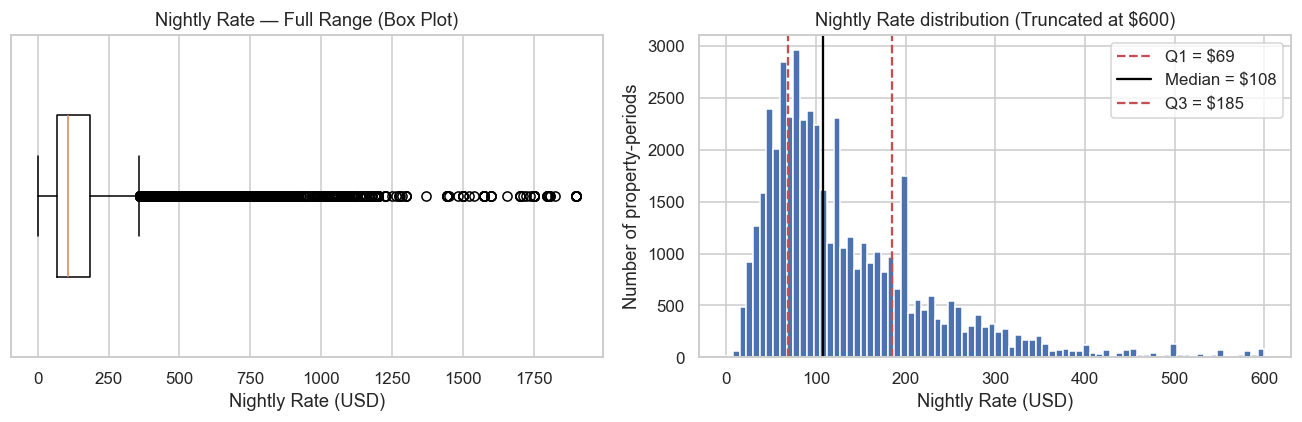

In [2]:
nr = df['Nightly Rate']

# Q1/Q3 are the 25th and 75th percentiles - the two values that bound the middle
# half of the market. The IQR is the width of that band
q1, q3 = nr.quantile(0.25), nr.quantile(0.75)
# Collect every spread statistic into one labelled table
summary = pd.Series({
    'Count (non-null)': nr.notna().sum(),
    'Missing':          nr.isna().sum(),
    'Minimum':          nr.min(),
    'Maximum':          nr.max(),
    'Range (max-min)':  nr.max() - nr.min(),
    'Q1 (25th pct)':    q1,
    'Median (50th pct)': nr.median(),
    'Q3 (75th pct)':    q3,
    'IQR (Q3-Q1)':      q3 - q1,
    'Mean':             nr.mean(),
    'Std deviation':    nr.std(),
})
print('Nightly Rate (USD) — spread statistics')
print('=' * 46)
print(summary.round(2).to_string())
print()
print('Rows used: {} of {} (null Nightly Rate: {})'.format(nr.notna().sum(), len(df), nr.isna().sum()))
print()

# List the most extreme listings so we can judge whether they are real or data errors
cols = ['Airbnb Property ID', 'Neighborhood', 'Listing Type', 'Bedrooms', 'Nightly Rate']
print('5 highest nightly rates')
# nlargest/nsmallest return whole ROWS ranked by one column. Because this is panel
# data these 5 rows can be the same property in 5 different periods, not 5 listings
print(df.nlargest(5, 'Nightly Rate')[cols].to_string(index=False))
print()
print('5 lowest nightly rates')
print(df.nsmallest(5, 'Nightly Rate')[cols].to_string(index=False))
print()

# How much of the market sits inside the IQR box vs out in the tail?
# between() gives True/False per row; .mean() turns that into a percentage
inside = nr.between(q1, q3).mean()
print('Share of listings priced between Q1 (${:.0f}) and Q3 (${:.0f}): {:.1%}'.format(q1, q3, inside))
print('Share priced above $500: {:.2%}   above $1,000: {:.2%}'.format((nr > 500).mean(), (nr > 1000).mean()))
print('99th percentile: ${:.2f}'.format(nr.quantile(0.99)))

# Box plot of the full range to show how far the outliers reach, next to a histogram
# zoomed into the main market to show where listings actually cluster
# The question asks about spread across different LISTINGS, but this is panel data:
# the five highest rows below are one property observed five times. Collapse to one
# median rate per property and confirm the answer is not an artefact of that.
per_listing = df.groupby('Airbnb Property ID')['Nightly Rate'].median()
print()
print('Same statistics at LISTING level (one median rate per property)')
print('  Distinct listings : {:,}  (from {:,} property-period rows)'.format(
    len(per_listing), len(df)))
print('  Range  : ${:,.2f}'.format(per_listing.max() - per_listing.min()))
print('  IQR    : ${:,.2f}   (vs ${:,.2f} at property-period level)'.format(
    per_listing.quantile(0.75) - per_listing.quantile(0.25), q3 - q1))
print('  Median : ${:,.2f}   (vs ${:,.2f})'.format(per_listing.median(), nr.median()))
print('  -> Materially the same answer, so the conclusion is not a panel artefact.')
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
try:                                  # matplotlib >= 3.11
    axes[0].boxplot(nr.dropna(), orientation='horizontal', widths=0.5)
except TypeError:                     # older matplotlib, e.g. some Colab images
    axes[0].boxplot(nr.dropna(), vert=False, widths=0.5)
axes[0].set_title('Nightly Rate — Full Range (Box Plot)')
axes[0].set_xlabel('Nightly Rate (USD)')
axes[0].set_yticks([])
# range= cuts the x-axis at $600 so the bars are visible; it hides the long tail,
# which is why the box plot beside it shows the full range instead
axes[1].hist(nr.dropna(), bins=80, range=(0, 600), color='#4C72B0', edgecolor='white')
axes[1].axvline(q1, color='#C44E52', ls='--', label='Q1 = ${:.0f}'.format(q1))
axes[1].axvline(nr.median(), color='black', ls='-', label='Median = ${:.0f}'.format(nr.median()))
axes[1].axvline(q3, color='#C44E52', ls='--', label='Q3 = ${:.0f}'.format(q3))
axes[1].set_title('Nightly Rate distribution (Truncated at $600)') # for readability
axes[1].set_xlabel('Nightly Rate (USD)')
axes[1].set_ylabel('Number of property-periods')
axes[1].legend()
plt.tight_layout()
plt.show()

### Findings — Question 1

Range = $1,899 (min $1, max $1,900). IQR = $116.12 (Q1 $69.00, Q3 $185.12), median $107.50.

The two measures tell very different stories, and the gap between them is the finding: the
range is more than **16 times** the IQR. The middle half of the Dallas market is packed into a
narrow $116 band just under $200 a night, while the full range is stretched across nearly $1,900
by a thin tail of luxury listings — only 3.7% of property-periods are priced above $500 and
1.1% above $1,000.

That makes the range a bad way to measure variability here. It is set by exactly two rows and
is dragged up by a single outlier, whereas the IQR describes where listings actually sit. The
mean ($157.17) sitting well above the median ($107.50) confirms the same right skew.

On the extremes. We did not remove them, but they should be read with suspicion. The five
highest rows are all the same property (ID 18054750, a 2-bedroom Central Dallas home) observed
in five different periods at $1,900 — a reminder that this is panel data, so the "top 5 rows"
are not 5 different listings. The $1 minimum is likewise one property (ID 20678468) listed with
0 bedrooms, which looks like a placeholder or data-entry error rather than a real market price.
A single bad row moves the range by hundreds of dollars and the IQR not at all.

For pricing guidance the IQR is the number to use, and the range is the one to avoid. The middle
half of Dallas listings all price within a $116 band of each other, so a typical host has room to
move by $10 or $20 and not much more. Only 3.7% of listings ever price above $500, which makes a
push toward premium positioning unrealistic advice for most of them. The range is set by a handful
of extreme listings a normal host will never compete with, so it describes a market they are not
in.

---
# Question 2 — Descriptive statistics for `booked_days` and `revenue`

> Provide a summary of key descriptive statistics (mean, median, standard deviation, minimum,
> and maximum) for booked_days and revenue. How do these statistics help you understand the
> overall performance of the properties?

Approach: One table with count, mean, median, std, min and max for both variables. The
mean-to-median ratio is the number to read: if the mean sits well above the median, a minority
of high earners is pulling the average up and the median is the better description of a typical
property.

Because null `booked_days` / `revenue` means "listed but never booked" (see Setup), we print the
table twice — once over booked property-periods only, and once with those rows counted as zero.
The second version is the honest picture of all listed inventory.

Null values — booked_days: 16861   revenue: 16861

A. Booked property-periods only (nulls excluded) — n = 31850
------------------------------------------------------------
         booked_days    revenue
Count       31850.00   31850.00
Mean           25.47    3134.13
Median         22.00    2025.00
Std dev        18.77    4249.34
Minimum         1.00      10.00
Maximum       173.00  134209.00

  booked_days  mean/median ratio = 1.16
  revenue      mean/median ratio = 1.55

B. All property-periods, unbooked counted as 0 — n = 48711
----------------------------------------------------------
         booked_days_all  revenue_all
Count           48711.00     48711.00
Mean               16.65      2049.27
Median              9.00       787.00
Std dev            19.42      3745.62
Minimum             0.00         0.00
Maximum           173.00    134209.00

  booked_days_all mean/median ratio = 1.85
  revenue_all  mean/median ratio = 2.60

Percentiles (booked periods only)
          booked_d

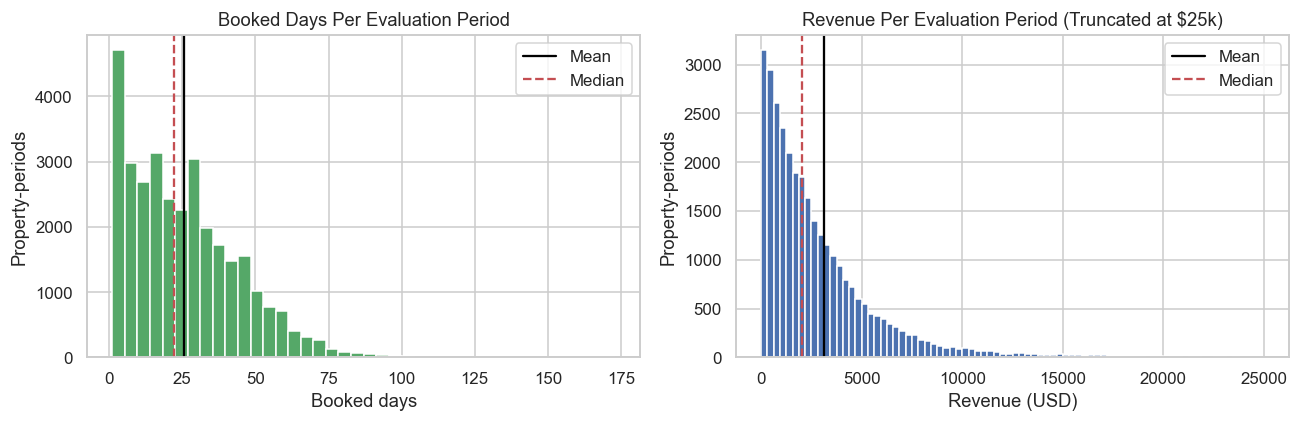

In [3]:
# Builds the same summary table for any set of columns, so we can run it twice:
# once on booked rows only, once with unbooked periods counted as zero
def describe_pair(frame, cols, label):
    # Dict-of-dicts -> DataFrame puts statistics in rows and variables in columns
    out = pd.DataFrame({
        c: {
            'Count':    frame[c].notna().sum(),
            'Mean':     frame[c].mean(),
            'Median':   frame[c].median(),
            'Std dev':  frame[c].std(),
            'Minimum':  frame[c].min(),
            'Maximum':  frame[c].max(),
        } for c in cols
    })
    print(label)
    print('-' * len(label))
    print(out.round(2).to_string())
    print()
    for col in cols:
        m, md_ = frame[col].mean(), frame[col].median()
        print('  {:<12} mean/median ratio = {:.2f}'.format(col, m / md_))
    print()
    return out

# How many property-periods have no booking data at all
print('Null values — booked_days: {}   revenue: {}'.format(
    df['booked_days'].isna().sum(), df['revenue'].isna().sum()))
print()

# Table A = booked periods only. Table B = the same stats with unbooked periods
# counted as zero, which is the honest view of all listed inventory
a = describe_pair(df, ['booked_days', 'revenue'],
                  'A. Booked property-periods only (nulls excluded) — n = {}'.format(
                      df['booked_days'].notna().sum()))
b = describe_pair(df.rename(columns={'booked_days_z': 'booked_days_all', 'revenue_z': 'revenue_all'}),
                  ['booked_days_all', 'revenue_all'],
                  'B. All property-periods, unbooked counted as 0 — n = {}'.format(len(df)))

# Percentiles give a fuller sense of the spread than min/max alone
pct = df[['booked_days', 'revenue']].quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.99]).round(2)
pct.index = ['10th pct', '25th pct', '50th pct', '75th pct', '90th pct', '99th pct']
print('Percentiles (booked periods only)')
print(pct.to_string())
print()
# Revenue earned by the top 10% of rows, divided by revenue earned by everyone
# A high number means earnings are concentrated in a few listings
top10_share = df.nlargest(int(0.10 * df['revenue'].notna().sum()), 'revenue')['revenue'].sum() / df['revenue'].sum()
print('Share of all revenue earned by the top 10% of property-periods: {:.1%}'.format(top10_share))

# Histograms of booked_days and revenue to show the shape behind those averages,
# with mean and median marked so the skew is visible
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['booked_days'].dropna(), bins=40, color='#55A868', edgecolor='white')
axes[0].axvline(df['booked_days'].mean(), color='black', ls='-', label='Mean')
axes[0].axvline(df['booked_days'].median(), color='#C44E52', ls='--', label='Median')
axes[0].set_title('Booked Days Per Evaluation Period')
axes[0].set_xlabel('Booked days'); axes[0].set_ylabel('Property-periods'); axes[0].legend()
axes[1].hist(df['revenue'].dropna(), bins=80, range=(0, 25000), color='#4C72B0', edgecolor='white')
axes[1].axvline(df['revenue'].mean(), color='black', ls='-', label='Mean')
axes[1].axvline(df['revenue'].median(), color='#C44E52', ls='--', label='Median')
axes[1].set_title('Revenue Per Evaluation Period (Truncated at $25k)') # for readability
axes[1].set_xlabel('Revenue (USD)'); axes[1].set_ylabel('Property-periods'); axes[1].legend()
plt.tight_layout()
plt.show()

### Findings — Question 2

The question asks how these statistics describe the overall performance of the properties, so the full listed population leads and the booked-only subset follows. They answer different questions, and the distance between them is itself the finding.

**All listed property-periods (n = 48,711), idle periods counted as zero:**

| | booked_days | revenue |
|---|---|---|
| Mean | 16.65 | $2,049.27 |
| Median | 9.00 | $787.00 |
| Std dev | 19.42 | $3,745.62 |
| Min | 0.00 | $0.00 |
| Max | 173.00 | $134,209.00 |

**On-market property-periods only (n = 41,400)** — excluding 7,311 rows with no 
`available_days` either, which are most likely off-market rather than idle:

| | booked_days | revenue |
|---|---|---|
| Median | 13.00 | $1,261 |
| Share earning nothing | 23.1% | 23.1% |

**Booked property-periods only (n = 31,850):**

| | booked_days | revenue |
|---|---|---|
| Mean | 25.47 | $3,134.13 |
| Median | 22.00 | $2,025.00 |
| Std dev | 18.77 | $4,249.34 |
| Min | 1.00 | $10.00 |
| Max | 173.00 | $134,209.00 |

What these say about performance: The typical booked property earns about $2,025 per
evaluation period on 22 booked days. The mean/median ratios separate the two variables
cleanly: `booked_days` is only mildly skewed (ratio 1.16), because it is physically capped
by the length of the period, and its max of 173 days is a real ceiling. Revenue doesn't really have a cap,
and its ratio of 1.55 plus a standard deviation ($4,249) larger than its own mean 
shows a small group of very high earners pulling the average up. The top 10% of
**booked** property-periods take 38.6% of the revenue they earn. Quoting the $3,134 mean as "typical" would
overstate what a normal host makes by more than 50%.

Why the two tables differ, and why it matters. 16,861
property-periods (34.6%) have no booked days at all. Counting those as zero, which is the
honest view of all listed inventory, the picture changes sharply: median revenue falls from
$2,025 to $787 and median booked days from 22 to 9. So roughly a third of Dallas
inventory earns nothing — though that figure depends on what counts as inventory. 7,311 of
those 16,861 rows have no `available_days` recorded either, so they were probably off the
market entirely rather than listed and unbooked. Restricting to rows we can confirm were
on the market, the idle share is **23.1%** and median revenue is **$1,261**. The direction is
unchanged on either reading; any performance claim simply needs to state which population it
describes.

Operationally, the striking number is not in the summary table at all. Among listings that were
actually on the market in a period, 23.1% earned nothing. That rises to 34.6% if the 7,311 rows
with no available days are counted too, but those read better as supply pulled off the market than
as listings that failed to book. We would defend the 23.1% in a presentation, and it still means
close to a quarter of active inventory sat empty.

The size of the gap is easy to state. A property that books earns a median of $2,025
in a period, and the same property sitting idle earns nothing. That makes empty
active listings the largest pool of missed revenue anywhere in this dataset, and it
is revenue from supply Airbnb has already signed up rather than supply it would have
to go find.


---
# Question 3 — Booking patterns: Superhosts vs non-Superhosts

> What can you infer about booking patterns for Superhosts compared to non-Superhosts?
> Determine the best way to visualize the booked_days data and explain your findings.

Chart choice and why: 
Side-by-side box plots, with overlapping density curves as a second view. A bar chart of two means would hide the spread, and spread is the whole point of a booking-pattern comparison — box plots show median, IQR and outliers for both groups at once, and the density curves show whether the two distributions have different *shapes* or just different centres.

Watch for: The groups are very different sizes, so we print group counts alongside and
compare medians as well as means.

Rows used: 31850 of 48711 (16861 dropped for null booked_days)

booked_days by Superhost status
                  Count   Mean  Median  Std dev    Q1    Q3    Max   IQR
Superhost status                                                        
Non-Superhost     18987  23.67    20.0    18.67   8.0  35.0  173.0  27.0
Superhost         12863  28.12    26.0    18.62  13.0  40.0  133.0  27.0

Difference in means  (Superhost - Non): +4.46 days
Difference in medians (Superhost - Non): +6.00 days
Superhost median is 1.3x the non-Superhost median

Share of property-periods with NO bookings at all:
Superhost status
Non-Superhost    42.1%
Superhost        19.2%


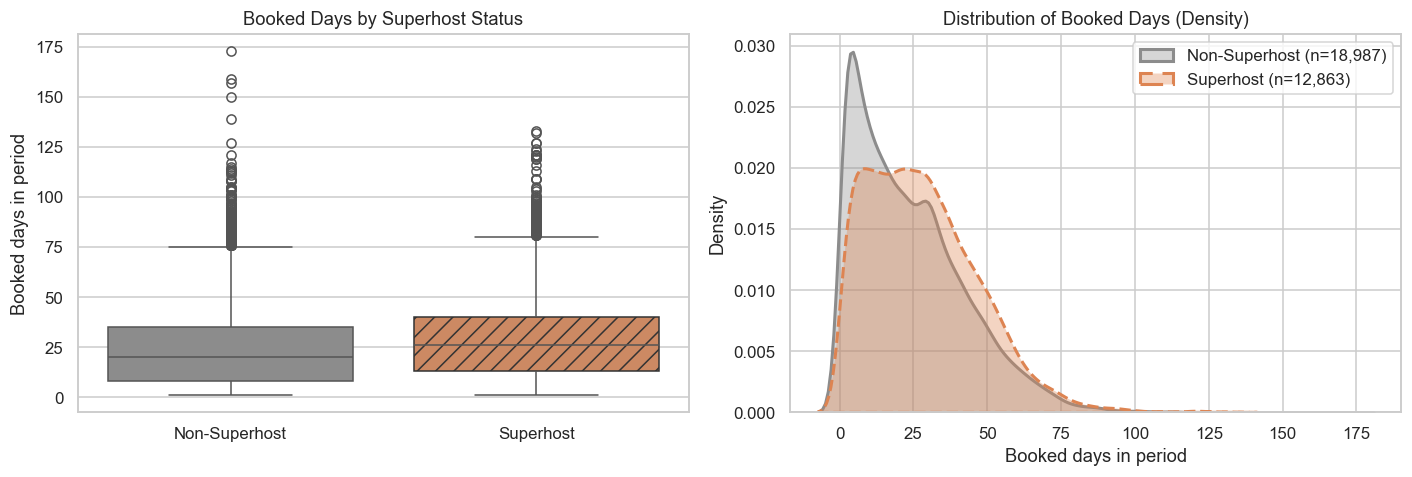

In [4]:
# Keep only rows that actually have booking data. subset= means 'judge missingness
# on this column only', not on the whole row
bd = df.dropna(subset=['booked_days'])
print('Rows used: {} of {} ({} dropped for null booked_days)'.format(
    len(bd), len(df), df['booked_days'].isna().sum()))
print()

# A groupby object: the same calculation gets applied once per group
grp = bd.groupby('Superhost status')['booked_days']
tbl = pd.DataFrame({
    'Count':  grp.count(),
    'Mean':   grp.mean(),
    'Median': grp.median(),
    'Std dev': grp.std(),
    'Q1':     grp.quantile(0.25),
    'Q3':     grp.quantile(0.75),
    'Max':    grp.max(),
})
tbl['IQR'] = tbl['Q3'] - tbl['Q1']
print('booked_days by Superhost status')
print(tbl.round(2).to_string())
print()

# Split into the two groups so we can difference them directly
sh = bd.loc[bd['Superhost'] == 1, 'booked_days']
non = bd.loc[bd['Superhost'] == 0, 'booked_days']
print('Difference in means  (Superhost - Non): {:+.2f} days'.format(sh.mean() - non.mean()))
print('Difference in medians (Superhost - Non): {:+.2f} days'.format(sh.median() - non.median()))
print('Superhost median is {:.1f}x the non-Superhost median'.format(sh.median() / non.median()))
print()

# Unbooked periods are excluded above; that itself differs by group, so report it
print('Share of property-periods with NO bookings at all:')
# Share of each group's rows that are missing - i.e. periods with zero bookings
# This runs on the FULL df, not bd, because bd has already dropped those rows
print((df.groupby('Superhost status')['booked_days'].apply(lambda s: s.isna().mean())
         .mul(100).round(1).astype(str) + '%').to_string())

# Box plot of booked days by group to compare medians, spread and outliers,
# plus density curves to show whether the two distributions differ in shape
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=bd, x='Superhost status', y='booked_days',
            order=['Non-Superhost', 'Superhost'],
            hue='Superhost status', hue_order=['Non-Superhost', 'Superhost'],
            palette=['#8C8C8C', '#DD8452'], legend=False, ax=axes[0])
hatch_second(axes[0])            # greyscale safety, see setup cell
axes[0].set_title('Booked Days by Superhost Status')
axes[0].set_xlabel(''); axes[0].set_ylabel('Booked days in period')

# Distinct linestyle as well as colour, so the two curves stay separable in print
for lab, colr, ls in [('Non-Superhost', '#8C8C8C', '-'), ('Superhost', '#DD8452', '--')]:
    sns.kdeplot(bd.loc[bd['Superhost status'] == lab, 'booked_days'],
                label='{} (n={:,})'.format(lab, int((bd['Superhost status'] == lab).sum())),
                fill=True, alpha=0.35, color=colr, linestyle=ls,
                linewidth=2, ax=axes[1])
axes[1].set_title('Distribution of Booked Days (Density)')
axes[1].set_xlabel('Booked days in period'); axes[1].set_ylabel('Density')
axes[1].legend(title='')
plt.tight_layout()
plt.show()

### Findings — Question 3

| | n | Mean | Median | Q1 | Q3 | IQR |
|---|---|---|---|---|---|---|
| Non-Superhost | 18,987 | 23.67 | 20.0 | 8.0 | 35.0 | 27.0 |
| Superhost | 12,863 | 28.12 | 26.0 | 13.0 | 40.0 | 27.0 |

Superhosts book +4.46 days more on the mean and +6.0 days more on the median — the median
gap is the larger of the two, so this is not a handful of outliers dragging an average. What the box plots add is that the IQR is identical at 27 days for both groups: the Superhost
distribution is not tighter or more consistent, it is the same shape shifted upward by about a week of bookings per period. Superhost listings are not a different kind of business, just a better-booked version of the same one.

The largest difference is one the box plots cannot show, because it lives in the rows we had
to drop. Among non-Superhosts, 42.1% of property-periods had no bookings at all; among
Superhosts, only 19.2%. Restricting to rows we can confirm were on the market (excluding the
7,311 with no `available_days`), the same gap holds at **28.0% against 14.5%**. So the real booking-pattern gap is not mainly that a booked Superhost books more nights — it is that a Superhost listing is less than half as likely to sit empty for an entire period. Any comparison restricted to booked rows understates the
advantage by a wide margin.

The idle rate is the finding worth acting on. A non-Superhost listing sits completely empty in
42.1% of periods against 19.2% for Superhosts, and because Airbnb earns per booked night, that
idle inventory is lost revenue on both sides of the marketplace. Whatever separates these two
groups more than halves the idle rate, which is worth considerably more than the extra week of
bookings among listings that were already booking.

---
# Question 4 — Seasonal patterns in booking days for Superhosts

> Are there any seasonal patterns in the booking days for Superhosts? Select the best approach
> to visualize the trend in booked_days over different periods and discuss the patterns you
> identify.

Chart choice and why: A line chart of mean `booked_days` by calendar month, restricted to
Superhosts. "Seasonal" means calendar months, so this is the first question that uses
`Scraped Date` rather than the period number. We add the non-Superhost line even though the
question doesn't ask for it: if both lines share the same shape, the pattern is the Dallas
market, not something about Superhosts.

Watch for: We check how many years and which months are actually present before averaging
months across years — the scrape is quarterly, so not every calendar month is covered.

Date range: 2016-08-01 to 2020-06-22
Distinct years  : [2016, 2017, 2018, 2019, 2020]
Distinct months present: [2, 3, 5, 6, 8, 9, 11, 12]
NOTE: scrapes are quarterly, so only 8 of 12 calendar months appear. Months with no
      scrape are absent from the chart, not zero.

Mean booked_days by calendar month (all months present in the data)
Superhost status  Non-Superhost  Superhost
Month                                     
Feb                       24.77      27.86
Mar                       21.27      17.42
May                       22.74      30.12
Jun                       13.35      21.25
Aug                       26.72      29.64
Sep                       17.94      19.00
Nov                       20.85      25.11
Dec                       17.86      21.62

Rows behind each month
Superhost status  Non-Superhost  Superhost
Month                                     
Feb                        4561       3329
Mar                          33         12
May                        4859  

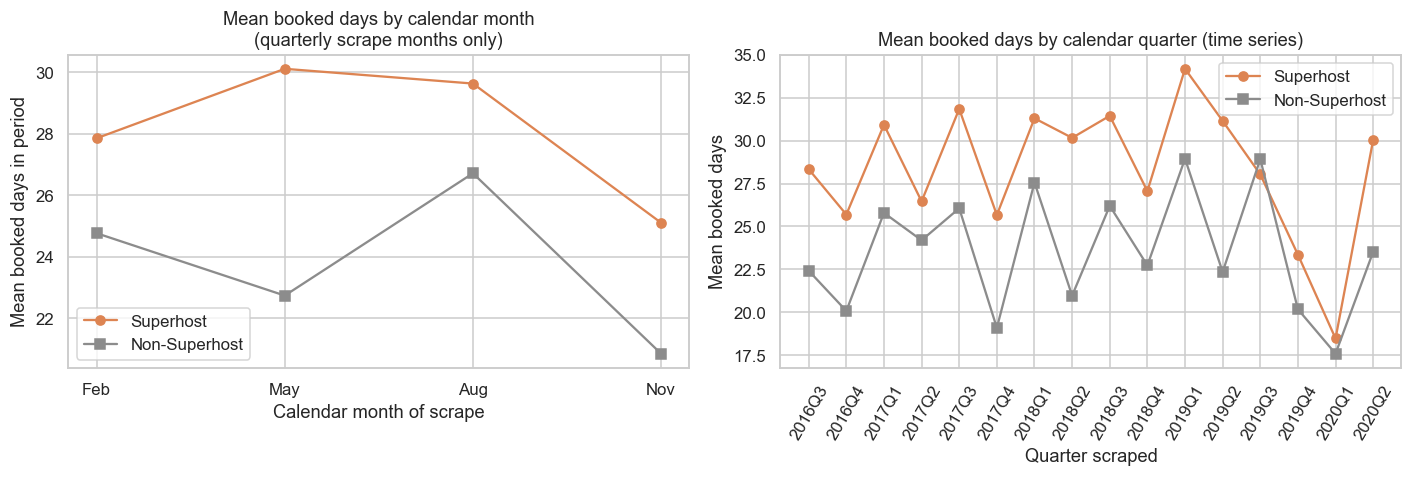


Mean booked_days by quarter (time series above)
Superhost status  Non-Superhost  Superhost
Scraped Date                              
2016Q3                    22.42      28.34
2016Q4                    20.07      25.69
2017Q1                    25.79      30.93
2017Q2                    24.19      26.46
2017Q3                    26.06      31.85
2017Q4                    19.09      25.67
2018Q1                    27.56      31.31
2018Q2                    20.97      30.17
2018Q3                    26.20      31.45
2018Q4                    22.73      27.06
2019Q1                    28.95      34.19
2019Q2                    22.35      31.15
2019Q3                    28.93      28.03
2019Q4                    20.17      23.36
2020Q1                    17.58      18.47
2020Q2                    23.52      30.05


In [5]:
# Q4: seasonality. This needs real calendar dates, so parse the date column first
df['Scraped Date'] = pd.to_datetime(df['Scraped Date'])
print('Date range: {} to {}'.format(df['Scraped Date'].min().date(), df['Scraped Date'].max().date()))
print('Distinct years  :', sorted(df['Scraped Date'].dt.year.unique()))
print('Distinct months present:', sorted(df['Scraped Date'].dt.month.unique()))
print('NOTE: scrapes are quarterly, so only {} of 12 calendar months appear. Months with no'
      .format(df['Scraped Date'].dt.month.nunique()))
print('      scrape are absent from the chart, not zero.')
print()

# Pull calendar month and year out of the date for grouping
# Added together rather than one at a time; separate inserts fragment the frame and
# emit a PerformanceWarning that would print into the graded PDF.
df = pd.concat([df, pd.DataFrame({
    'Month': df['Scraped Date'].dt.month,
    'Year': df['Scraped Date'].dt.year,
}, index=df.index)], axis=1)
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

bd = df.dropna(subset=['booked_days'])
# Mean, median and row count of booked days for each month/group combination
monthly = (bd.groupby(['Month', 'Superhost status'])['booked_days']
             .agg(['mean', 'median', 'count']).round(2).reset_index())
# pivot reshapes long -> wide: one row per month, one column per group
piv_mean = monthly.pivot(index='Month', columns='Superhost status', values='mean')
piv_n = monthly.pivot(index='Month', columns='Superhost status', values='count')

print('Mean booked_days by calendar month (all months present in the data)')
print(piv_mean.rename(index=month_names).round(2).to_string())
print()
print('Rows behind each month')
print(piv_n.rename(index=month_names).astype(int).to_string())
print()

# Four months hold only a handful of straggler scrapes. Averaging 12 rows next to 3,300
# would invent a seasonal swing that is really sampling noise, so we read the pattern off
# the well-sampled months only and say which those are
# .all(axis=1) demands the threshold is met in BOTH columns, so a month only counts
# as well-sampled if both groups have enough rows
well = piv_n[(piv_n >= 500).all(axis=1)].index.tolist()
thin = [m for m in piv_n.index if m not in well]
print('Well-sampled months (>=500 rows in BOTH groups):', [month_names[m] for m in well])
print('Thin months excluded from the chart          :',
      ['{} (n={})'.format(month_names[m], int(piv_n.loc[m].sum())) for m in thin])
print()

# Peak and trough months, read off the well-sampled months only
pm = piv_mean.loc[well]
sh_m = pm['Superhost']
print('Superhost peak month : {} ({:.1f} booked days)'.format(month_names[sh_m.idxmax()], sh_m.max()))
print('Superhost low month  : {} ({:.1f} booked days)'.format(month_names[sh_m.idxmin()], sh_m.min()))
print('Peak-to-trough swing : {:.1f} days ({:.0%} above the low month)'.format(
    sh_m.max() - sh_m.min(), (sh_m.max() - sh_m.min()) / sh_m.min()))
non_m = pm['Non-Superhost']
print('Non-Superhost peak   : {}   low: {}   swing: {:.1f} days'.format(
    month_names[non_m.idxmax()], month_names[non_m.idxmin()], non_m.max() - non_m.min()))
# Vertical gap between the two lines on the chart: how many more days a Superhost
# listing books than a non-Superhost one, in each month
print()
lead = (pm['Superhost'] - pm['Non-Superhost']).rename(index=month_names).round(2)
lead.index.name = None          # drop the stray 'Month' header pandas prints
print('Superhost lead in mean booked days (Superhost - Non-Superhost), by month:')
print(lead.to_string())

# Which month is each group's own best? The two groups do not peak together, so rank
# each month within its own group rather than comparing the levels across groups.
print()
print('Rank of each month within its OWN group (1 = that group\'s best month)')
ranks = pd.DataFrame({
    'Superhost rank':     pm['Superhost'].rank(ascending=False).astype(int),
    'Non-Superhost rank': pm['Non-Superhost'].rank(ascending=False).astype(int),
}).rename(index=month_names)
print(ranks.to_string())

# Is the May divergence a stable seasonal rule or driven by particular years?
print()
print('Mean booked days and gap, by year and month (well-sampled months only)')
wy = bd[bd['Month'].isin(well)]
by_year = wy.groupby(['Year', 'Month', 'Superhost status'])['booked_days'].mean().unstack()
by_year['Gap'] = by_year['Superhost'] - by_year['Non-Superhost']
by_year.index = by_year.index.set_levels([month_names[m] for m in sorted(well)], level=1)
print(by_year.round(2).to_string())
print()
print('Years each well-sampled month is observed in (they are NOT the same set):')
for m in well:
    yrs = sorted(wy.loc[wy['Month'] == m, 'Year'].unique())
    print('  {:<4} {}'.format(month_names[m], yrs))

# Left: line chart of booked days by calendar month to show the seasonal cycle
# Right: the same measure by quarter over time, to separate cycle from trend
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for lab, colr, mk in [('Superhost', '#DD8452', 'o'), ('Non-Superhost', '#8C8C8C', 's')]:
    axes[0].plot(range(len(well)), pm[lab], marker=mk, color=colr, label=lab)
axes[0].set_xticks(range(len(well)))
axes[0].set_xticklabels([month_names[m] for m in well])
axes[0].set_title('Mean booked days by calendar month\n(quarterly scrape months only)')
axes[0].set_xlabel('Calendar month of scrape')
axes[0].set_ylabel('Mean booked days in period')
axes[0].legend(title='')

# Second view: the actual time series, so a repeating cycle can be told apart from a trend
# .dt.to_period('Q') buckets each date into its calendar quarter (e.g. 2019Q2)
# .unstack() then moves the Superhost labels up into columns
ts = (bd.groupby([bd['Scraped Date'].dt.to_period('Q'), 'Superhost status'])['booked_days']
        .mean().unstack())
ts.index = ts.index.astype(str)
for lab, colr, mk in [('Superhost', '#DD8452', 'o'), ('Non-Superhost', '#8C8C8C', 's')]:
    axes[1].plot(ts.index, ts[lab], marker=mk, color=colr, label=lab)
axes[1].set_title('Mean booked days by calendar quarter (time series)')
axes[1].set_xlabel('Quarter scraped'); axes[1].set_ylabel('Mean booked days')
axes[1].tick_params(axis='x', rotation=60)
axes[1].legend(title='')
plt.tight_layout()
plt.show()

print()
print('Mean booked_days by quarter (time series above)')
print(ts.round(2).to_string())

### Findings — Question 4

A sampling caveat first, because it changes the answer. The data is scraped quarterly,
so only 8 of 12 calendar months appear at all, and 4 of those (Mar, Jun, Sep, Dec) hold just a
few dozen straggler rows against 3,000+ in the real scrape months. Reading a "March trough" off
12 Superhost rows would be inventing a season out of sampling noise. We therefore read the
pattern off the four well-sampled months — February, May, August, November — and exclude the
rest from the chart.

Mean booked days, Superhosts: Feb 27.9 · May 30.1 · Aug 29.6 · Nov 25.1.
Mean booked days, non-Superhosts: Feb 24.8 · May 22.7 · Aug 26.7 · Nov 20.9.

The pattern: There is a clear and modest season. Superhost bookings peak in May (30.1
days), hold nearly as high through August (29.6), and fall to a low in November (25.1) —
a 5.0-day swing, about 20% between the best and worst month. Spring and summer are the
Dallas booking season; late autumn is the trough.

The season is broadly the market, not the badge — but the two groups do not peak in the
same month. Both trough in November (Superhosts 25.1, non-Superhosts 20.9) and both run
stronger through spring and summer, so the underlying cycle is Dallas demand rather than
anything Superhosts do. The peaks differ, though. Ranked within its own group, May is the
Superhosts' best month but only the third of four for non-Superhosts, whose best month is
August. Superhosts also sit above non-Superhosts in every month, by 2.9 to 7.4 days.

May is where the two groups come apart, and it is the finding worth naming. The gap runs 3.1
days in February, 2.9 in August and 4.3 in November — but 7.4 in May, roughly two and a half
times the August gap. Superhosts are at their strongest (30.1 days) in the same month
non-Superhosts are near their weakest (22.7, above only November). So spring demand is not
shared out evenly: whatever arrives in Dallas in May, Superhost listings absorb far more of it,
and the single peak-season month is the one where the two groups least resemble each other.

Two qualifications, because the pooled figure hides them. First, the May gap is not a fixed
seasonal rule — it is +2.1 days in 2017, then +9.4 in 2018, +8.8 in 2019 and +6.5 in 2020. In
2017 May was actually the narrowest of that year's four gaps, so this is a 2018-onward pattern
rather than a permanent feature of Dallas Mays. Second, the two peak months are not measured
over the same years: May is observed in 2017-2020 and August in 2016-2019, so part of the
May-versus-August comparison is a comparison of different years — the 2020 recovery sits inside
the May average and not inside August's. The direction survives both, but the size should be
quoted as an average over four unlike years.

The quarterly time series adds a caution about reading months across years. It shows the
seasonal cycle repeating on top of a mild upward drift from 2016 to 2019, then a visible dip in
2020 Q1 (Superhost mean 18.5 booked days, the lowest point in the series) as COVID hit. Since
the monthly averages pool five years together, that shock is silently mixed into the Feb figure.

For capacity and pricing planning, a 5.0-day swing between May and November is forecastable and
market-wide, so it should not be read as host performance. Both groups share the November trough,
which says the cycle is Dallas demand rather than the badge. What is worth acting on is where they
diverge: the premium is widest in May, the Superhost peak and a month when non-Superhosts sit near
their own floor. That argues for putting pricing and availability support in front of
non-Superhosts ahead of spring, with the caveat that this gap only opens from 2018 onward and
should be confirmed on current data first.

---
# Question 5 — Superhost status and number of reviews

> How does Superhost status impact the number of reviews a property receives? Choose an
> appropriate method to compare the numReviews_pastYear for Superhosts and non-Superhosts.

Method choice and why: Group summary statistics plus box plots, backed by two significance
tests. Review counts are right-skewed and the two groups differ in size and variance, so we use
Welch's t-test (does not assume equal variances) for the means and Mann-Whitney U as a
non-parametric check that does not assume normality. If both agree, the gap is not sampling
noise.

Important caveat for the written answer: This is correlational, and the direction is
ambiguous: Superhost status is awarded partly on the basis of review activity, so we cannot
claim the badge causes reviews. It is at least as likely that reviews cause the badge.

Rows used: 37492 of 48711 (11219 dropped for null numReviews_pastYear)

numReviews_pastYear by Superhost status
                  Count    Mean  Median  Std dev    Q1     Q3     Max
Superhost status                                                     
Non-Superhost     22546  240.49    27.0   601.66   5.0  184.0  3305.0
Superhost         14946  138.78    46.0   288.59  20.0  131.0  3133.0

Difference in means  : -101.71 reviews  (Superhost 138.8 vs 240.5)
Difference in medians: +19.0 reviews  (Superhost 46 vs 27)
Superhost mean is 0.58x the non-Superhost mean

Welch's t-test (unequal variances)
  t-statistic = -21.870
  p-value     = 2.614e-105  (< 0.001)
Mann-Whitney U (non-parametric check)
  U-statistic = 199,394,438
  p-value     = 2.198e-199  (< 0.001)

Cohen's d (effect size) = -0.203
  For scale: 0.2 small, 0.5 medium, 0.8 large.


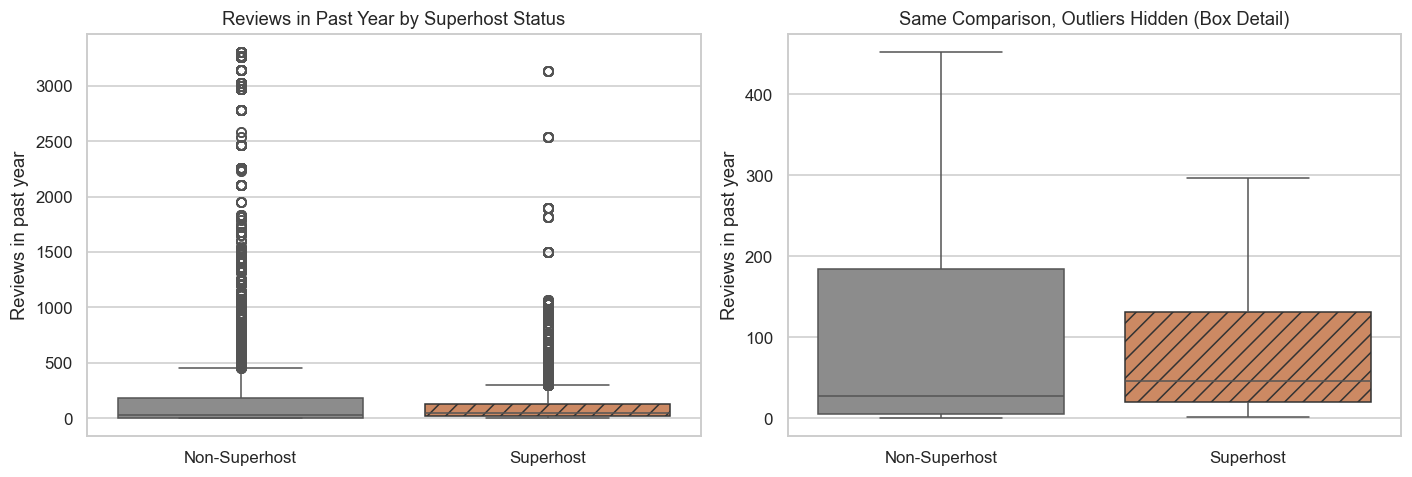

In [6]:
rv = df.dropna(subset=['numReviews_pastYear'])
print('Rows used: {} of {} ({} dropped for null numReviews_pastYear)'.format(
    len(rv), len(df), df['numReviews_pastYear'].isna().sum()))
print()

# Summary table of review counts for each group
grp = rv.groupby('Superhost status')['numReviews_pastYear']
tbl = pd.DataFrame({'Count': grp.count(), 'Mean': grp.mean(), 'Median': grp.median(),
                    'Std dev': grp.std(), 'Q1': grp.quantile(0.25), 'Q3': grp.quantile(0.75),
                    'Max': grp.max()})
print('numReviews_pastYear by Superhost status')
print(tbl.round(2).to_string())
print()

# Split the two groups so they can be compared and tested
sh = rv.loc[rv['Superhost'] == 1, 'numReviews_pastYear']
non = rv.loc[rv['Superhost'] == 0, 'numReviews_pastYear']
print('Difference in means  : {:+.2f} reviews  (Superhost {:.1f} vs {:.1f})'.format(
    sh.mean() - non.mean(), sh.mean(), non.mean()))
print('Difference in medians: {:+.1f} reviews  (Superhost {:.0f} vs {:.0f})'.format(
    sh.median() - non.median(), sh.median(), non.median()))
print('Superhost mean is {:.2f}x the non-Superhost mean'.format(sh.mean() / non.mean()))
print()

# equal_var=False makes this Welch's t-test, which does not assume the two groups
# have the same variance or size - both are true here
t, p = stats.ttest_ind(sh, non, equal_var=False)
print("Welch's t-test (unequal variances)")
print('  t-statistic = {:.3f}'.format(t))
print('  p-value     = {:.3e}{}'.format(p, '  (< 0.001)' if p < 0.001 else ''))
# Compares ranks rather than means, so a few huge values cannot distort it
u, pu = stats.mannwhitneyu(sh, non, alternative='two-sided')
print('Mann-Whitney U (non-parametric check)')
print('  U-statistic = {:,.0f}'.format(u))
print('  p-value     = {:.3e}{}'.format(pu, '  (< 0.001)' if pu < 0.001 else ''))
# Effect size: a significant p-value on 37k rows says little on its own
# Cohen's d = gap between means measured in standard deviations. On 37k rows almost
# any gap is 'significant', so this says whether it is actually BIG
pooled = np.sqrt(((len(sh)-1)*sh.var() + (len(non)-1)*non.var()) / (len(sh)+len(non)-2))
print("\nCohen's d (effect size) = {:.3f}".format((sh.mean() - non.mean()) / pooled))
print('  For scale: 0.2 small, 0.5 medium, 0.8 large.')

# Box plots of reviews by group. The second hides outliers so the boxes themselves
# are readable - the tail is so long it flattens the first chart
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=rv, x='Superhost status', y='numReviews_pastYear',
            order=['Non-Superhost', 'Superhost'],
            hue='Superhost status', hue_order=['Non-Superhost', 'Superhost'],
            palette=['#8C8C8C', '#DD8452'], legend=False, ax=axes[0])
hatch_second(axes[0])            # greyscale safety, see setup cell
axes[0].set_title('Reviews in Past Year by Superhost Status')
axes[0].set_xlabel(''); axes[0].set_ylabel('Reviews in past year')

sns.boxplot(data=rv, x='Superhost status', y='numReviews_pastYear',
            order=['Non-Superhost', 'Superhost'],
            hue='Superhost status', hue_order=['Non-Superhost', 'Superhost'],
            palette=['#8C8C8C', '#DD8452'], legend=False, showfliers=False, ax=axes[1])
hatch_second(axes[1])            # greyscale safety, see setup cell
axes[1].set_title('Same Comparison, Outliers Hidden (Box Detail)')
axes[1].set_xlabel(''); axes[1].set_ylabel('Reviews in past year')
plt.tight_layout()
plt.show()

### Q5 follow-up — the mean and the median disagree, so we check why

The table above shows something odd: Superhosts have a higher median review count but a
lower mean. When those two point in opposite directions, a skewed tail is driving the mean,
and we should find out what is in that tail before writing an answer.

Our hypothesis: `numReviews_pastYear` scales with how many listings a host operates, so large
commercial operators sit in the tail — and those operators are concentrated among
non-Superhosts. We test it by counting listings per host and re-running the comparison on
single-listing hosts only, which removes the confound.

Mean reviews by size of host portfolio (distinct listings operated)
           count   mean  median
n_props                        
1 listing  10569   19.8     9.0
2           4858   35.2    18.0
3-5         5635   55.0    28.0
6-20        6438  260.2   110.0
21+         9992  513.5   188.0

-> Review counts rise steeply with portfolio size, so this column reflects the HOST,
   not just the property.

Portfolio size by Superhost status
                   mean  median
Superhost status               
Non-Superhost     72.79     5.0
Superhost         39.54     3.0

-> The average non-Superhost ROW belongs to a host with a far larger portfolio, which
   is what pulls their MEAN review count up. This is a row-weighting effect: a large
   operator contributes one row per listing per period. At HOST level the median host
   in either group runs a single listing.

Like-for-like comparison: single-listing hosts only (n = 10569)
                  count   mean  median    std
Superhost status     

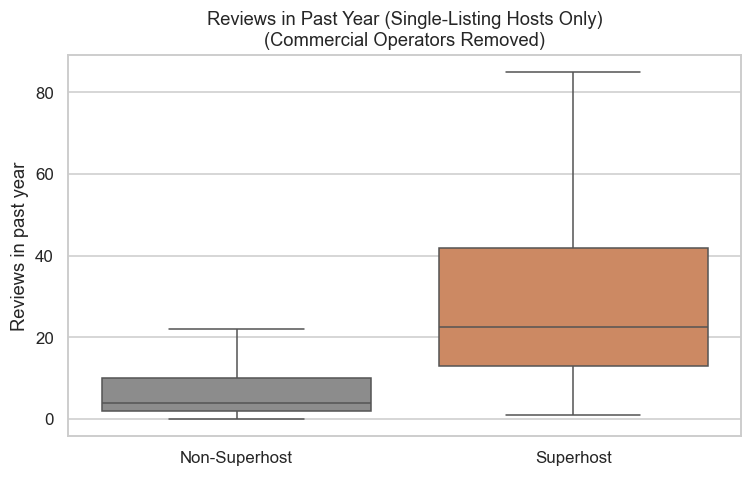

In [7]:
# How many distinct properties does each host operate?
# nunique() counts DISTINCT properties per host, so a host appearing in many periods
# is still counted once per property
props_per_host = rv.groupby('Airbnb Host ID')['Airbnb Property ID'].nunique().rename('n_props')
# join(..., on=) attaches that host-level count back onto every row of that host
rv2 = rv.join(props_per_host, on='Airbnb Host ID')

# Does review count track how many listings a host runs?
print('Mean reviews by size of host portfolio (distinct listings operated)')
# pd.cut sorts a numeric column into labelled bands. Edges are (0,1], (1,2] ... so
# '1 listing' means exactly one
bands = pd.cut(rv2['n_props'], [0, 1, 2, 5, 20, 10000],
               labels=['1 listing', '2', '3-5', '6-20', '21+'])
print(rv2.groupby(bands, observed=True)['numReviews_pastYear']
         .agg(['count', 'mean', 'median']).round(1).to_string())
print()
print('-> Review counts rise steeply with portfolio size, so this column reflects the HOST,')
print('   not just the property.')
print()
# Compare typical portfolio size between the two groups
print('Portfolio size by Superhost status')
print(rv2.groupby('Superhost status')['n_props'].agg(['mean', 'median']).round(2).to_string())
print()
print('-> The average non-Superhost ROW belongs to a host with a far larger portfolio, which')
print('   is what pulls their MEAN review count up. This is a row-weighting effect: a large')
print('   operator contributes one row per listing per period. At HOST level the median host')
print('   in either group runs a single listing.')
print()

# Re-run the comparison with the confound removed
# Hosts with exactly one listing: removes commercial operators, which is the
# confound that made the mean and median disagree above
single = rv2[rv2['n_props'] == 1]
print('=' * 62)
print('Like-for-like comparison: single-listing hosts only (n = {})'.format(len(single)))
print('=' * 62)
print(single.groupby('Superhost status')['numReviews_pastYear']
            .agg(['count', 'mean', 'median', 'std']).round(2).to_string())
print()
a = single.loc[single['Superhost'] == 1, 'numReviews_pastYear']
b = single.loc[single['Superhost'] == 0, 'numReviews_pastYear']
print('Superhost mean is {:.2f}x the non-Superhost mean   ({:.1f} vs {:.1f})'.format(
    a.mean() / b.mean(), a.mean(), b.mean()))
print('Superhost median is {:.2f}x the non-Superhost median ({:.1f} vs {:.1f})'.format(
    a.median() / b.median(), a.median(), b.median()))
print("Welch's t-test p-value : {:.3e}".format(stats.ttest_ind(a, b, equal_var=False)[1]))
print('Mann-Whitney U p-value : {:.3e}'.format(stats.mannwhitneyu(a, b, alternative='two-sided')[1]))

# Box plot of reviews for single-listing hosts only - the like-for-like comparison,
# with commercial operators removed
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=single, x='Superhost status', y='numReviews_pastYear',
            order=['Non-Superhost', 'Superhost'],
            hue='Superhost status', hue_order=['Non-Superhost', 'Superhost'],
            palette=['#8C8C8C', '#DD8452'], legend=False, showfliers=False, ax=ax)
ax.set_title('Reviews in Past Year (Single-Listing Hosts Only)\n(Commercial Operators Removed)')
ax.set_xlabel(''); ax.set_ylabel('Reviews in past year')
plt.tight_layout()
plt.show()

### Findings — Question 5

The headline comparison contradicts itself, and that is the interesting part. Across all
37,492 rows with review data, Superhosts have a higher median (46 vs 27 reviews) but a
lower mean (138.8 vs 240.5). Both tests are significant (Welch p ≈ 3e-105, Mann-Whitney
p ≈ 2e-199), but they are significant in opposite directions, so significance is not the issue
— on 37,000 rows almost anything reaches significance, which is why we also report Cohen's d
(-0.20, small). A p-value cannot tell us which of two contradictory answers is right.

What is in the tail. `numReviews_pastYear` rises steeply with the size of the host's
portfolio — from a mean of 19.8 reviews for single-listing hosts to 513.5 for hosts with 21+
listings. The column reflects the host, not the individual property. And the average non-Superhost *row*
belongs to a host operating 72.8 listings, against 39.5 for Superhost rows — a large operator
contributes one row per listing per period, so a handful of them dominate the non-Superhost
mean. (At host level the comparison reverses and the median host in either group runs a single
listing; it is the row weighting, not the hosts, that creates the confound.) So the non-Superhost mean
is inflated by large commercial operators, who accumulate enormous review counts and are
under-represented among Superhosts (21.7% of rows from hosts with 21+ listings carry the badge,
against 32.7% of rows overall).

The like-for-like answer. Restricting to hosts with exactly one listing (n = 10,569) removes
the confound, and the contradiction disappears — both statistics now point the same way:

| Single-listing hosts | n | Mean | Median |
|---|---|---|---|
| Non-Superhost | 6,547 | 12.5 | 4.0 |
| Superhost | 4,022 | 31.7 | 22.5 |

Superhosts receive 2.5x the mean and 5.6x the median number of reviews (both p < 0.001).
That is the finding: Superhost status is associated with substantially more reviews, and the
raw comparison hid it entirely behind a composition effect.

Causation caveat: This is correlational, and the direction is genuinely ambiguous — Airbnb
awards Superhost status partly on the basis of review activity, so it is at least as plausible
that reviews cause the badge as the reverse. We cannot separate the two with this data.

Reviews are the trust signal the marketplace runs on. Once the portfolio-size confound is removed,
single-listing Superhosts receive 5.6x the median reviews of comparable non-Superhosts, and more
reviews mean less uncertainty for guests and cheaper matching for Airbnb. The caution is that the
causal direction is genuinely ambiguous, since the badge is awarded partly on review activity, so
neither Airbnb nor a host can treat earning the badge as a route to more reviews.

---
# Question 6 — Histogram of revenue by Superhost status

> Use a histogram to visualize the distribution of revenue for listings. How does the
> distribution differ between properties with Superhost status and those without?

Approach: Revenue is heavily right-skewed, and a plain histogram is one tall bar near zero and a flat invisible tail. We show two versions on shared bins: the raw scale, and a log-scaled x-axis where the shape of both distributions is actually readable. We read the answer off the log version and say so.

Decision stated explicitly: property-periods with no bookings (null revenue) are excluded
from the histograms, because a log axis cannot show zero. Their counts are printed below so the
exclusion is visible.

Rows used: 31850 of 48711 (16861 excluded — no bookings in the period)

revenue by Superhost status
                           Non-Superhost  Superhost
Count                           18987.00   12863.00
Mean                             2938.92    3422.28
Median                           1868.00    2229.00
Std dev                          3862.47    4748.83
Skewness                            4.83       7.24
Max                             77500.00  134209.00
Rows with revenue == 0              0.00       0.00
Unbooked periods excluded       13804.00    3057.00

Both groups are strongly right-skewed (skew >> 0), so the median describes a typical
property far better than the mean does.

Median revenue: Superhost $2,229 vs Non-Superhost $1,868  (+19%)
Mean revenue  : Superhost $3,422 vs Non-Superhost $2,939  (+16%)


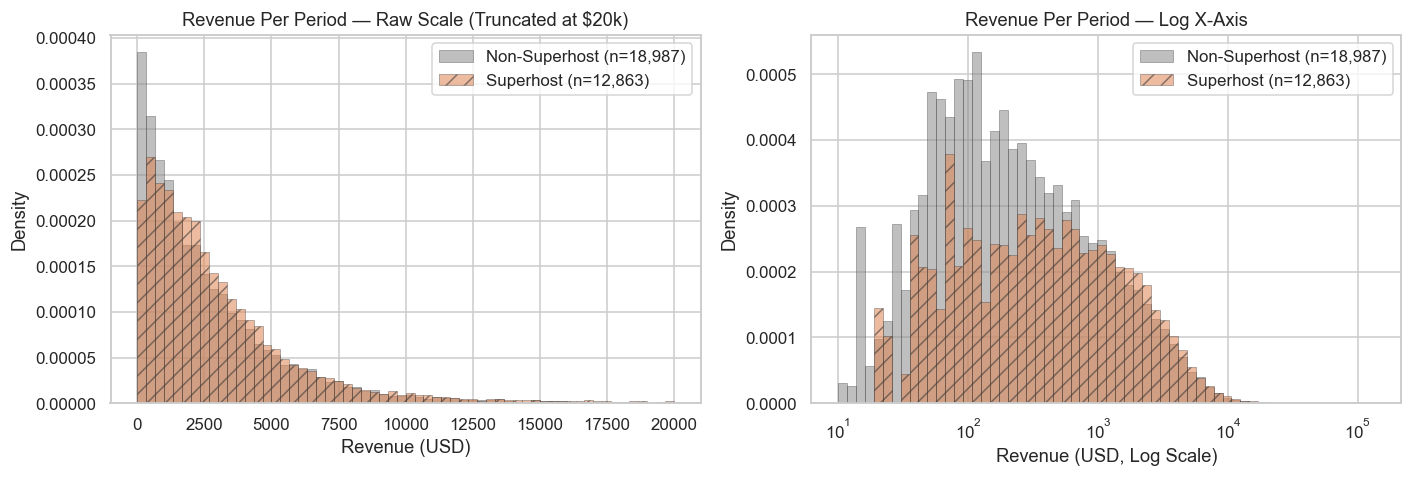

In [8]:
rev = df.dropna(subset=['revenue'])
print('Rows used: {} of {} ({} excluded — no bookings in the period)'.format(
    len(rev), len(df), df['revenue'].isna().sum()))
print()

# Per-group revenue statistics, including skewness to quantify the right tail
stats_tbl = pd.DataFrame({
    lab: {
        'Count':            g['revenue'].count(),
        'Mean':             g['revenue'].mean(),
        'Median':           g['revenue'].median(),
        'Std dev':          g['revenue'].std(),
        'Skewness':         g['revenue'].skew(),
        'Max':              g['revenue'].max(),
        'Rows with revenue == 0': int((g['revenue'] == 0).sum()),
        'Unbooked periods excluded': int(df[(df['Superhost status'] == lab)]['revenue'].isna().sum()),
    } for lab, g in rev.groupby('Superhost status')
})
print('revenue by Superhost status')
print(stats_tbl.round(2).to_string())
print()
print('Both groups are strongly right-skewed (skew >> 0), so the median describes a typical')
print('property far better than the mean does.')
print()
# Headline medians and means for the write-up
sh = rev.loc[rev['Superhost'] == 1, 'revenue']
non = rev.loc[rev['Superhost'] == 0, 'revenue']
print('Median revenue: Superhost ${:,.0f} vs Non-Superhost ${:,.0f}  ({:+.0%})'.format(
    sh.median(), non.median(), sh.median() / non.median() - 1))
print('Mean revenue  : Superhost ${:,.0f} vs Non-Superhost ${:,.0f}  ({:+.0%})'.format(
    sh.mean(), non.mean(), sh.mean() / non.mean() - 1))

# Both groups must share identical bins or the histograms cannot be compared
# linspace = evenly spaced; logspace = evenly spaced ON a log axis, so the bars
# stay equal width once the x-axis is logged
bins_raw = np.linspace(0, 20000, 61)
bins_log = np.logspace(np.log10(max(rev['revenue'].min(), 1)), np.log10(rev['revenue'].max()), 61)

# Two overlapping histograms of revenue by group: raw scale on the left, log x-axis
# on the right where the skew stops hiding the shape
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
# Hatch as well as colour: the two fills are near-identical in greyscale
for lab, colr, htch in [('Non-Superhost', '#8C8C8C', None), ('Superhost', '#DD8452', '//')]:
    s = rev.loc[rev['Superhost status'] == lab, 'revenue']
    # density=True converts counts to proportions. Essential here: there are far more
    # non-Superhost rows, so raw counts would make that group look taller everywhere
    # alpha makes the overlapping region visible
    lab_n = '{} (n={:,})'.format(lab, len(s))
    axes[0].hist(s, bins=bins_raw, alpha=0.55, label=lab_n, color=colr, density=True,
                 hatch=htch, edgecolor='#333333', linewidth=0.4)
    axes[1].hist(s, bins=bins_log, alpha=0.55, label=lab_n, color=colr, density=True,
                 hatch=htch, edgecolor='#333333', linewidth=0.4)
axes[0].set_title('Revenue Per Period — Raw Scale (Truncated at $20k)')
axes[0].set_xlabel('Revenue (USD)'); axes[0].set_ylabel('Density'); axes[0].legend(title='')
axes[1].set_xscale('log')
axes[1].set_title('Revenue Per Period — Log X-Axis')
axes[1].set_xlabel('Revenue (USD, Log Scale)'); axes[1].set_ylabel('Density'); axes[1].legend(title='')
plt.tight_layout()
plt.show()

### Findings — Question 6

Reading the log-scale chart, not the raw one: Revenue is so heavily right-skewed (skewness
7.24 for Superhosts, 4.83 for non-Superhosts) that the raw histogram is a spike near zero
and an invisible tail — you cannot compare shapes on it. On the log x-axis both distributions
resolve into a clear roughly log-normal bell, and that is the version we read the answer from.

| | n | Mean | Median | Skew | Max |
|---|---|---|---|---|---|
| Non-Superhost | 18,987 | $2,938.92 | $1,868 | 4.83 | $77,500 |
| Superhost | 12,863 | $3,422.28 | $2,229 | 7.24 | $134,209 |

How the distributions differ: They have the same shape, shifted: the Superhost curve sits
to the right of the non-Superhost curve across essentially its whole body, with a median 19%
higher ($2,229 vs $1,868) and a mean 16% higher. The shift is bigger at the median than at
the mean, meaning the Superhost advantage is a broad-based shift of ordinary listings rather
than a few stars. Superhosts are also more skewed (7.24 vs 4.83) and hold the single largest
observation ($134,209), so the top of the market is Superhost territory — but that tail is not
what moves the median.

Two things the histogram cannot show. First, no row records revenue of exactly $0 — the
minimum is $10 — so the "zero bar" people expect is absent by construction. Second, and more
important, we excluded 16,861 property-periods with no bookings (a log axis cannot plot
zero), and they are not evenly split: 13,804 non-Superhost vs 3,057 Superhost. Both
histograms are therefore conditioned on having earned anything at all, which flatters
non-Superhosts. Including the idle periods as zero would widen the Superhost advantage
considerably.

The Superhost curve is the same shape shifted right, with a median 19% higher, and the breadth of
that shift matters more than the tail: it is a lift across ordinary listings rather than a handful
of stars. But it describes which listings hold the badge, not what the badge does. Question 7 shows
the badge itself does not produce the advantage, so this is not evidence that applying Superhost
standards more widely would move revenue. The comparison also excludes idle periods, so if
anything it understates the gap.

---
# Question 7 — Revenue before vs after gaining Superhost status

> Create a bar chart comparing the average revenue for properties before and after gaining
> Superhost status. Does the revenue increase for properties that become Superhosts?

How this is done correctly: This is the question the panel structure exists for. We filter to
rows where `superhost_change_gain_superhost == 1` — exactly the property-periods in which the
badge was gained. Within those rows, `prev_revenue` is the before value and `revenue` is the
after value for the same property.

Comparing all Superhost revenue against all non-Superhost revenue would answer a different and
much weaker question, because it compares different properties. Here each property is its own
control.

We therefore also run a paired t-test and report the mean of the per-property change, not
just the difference between two group means.

Property-periods where Superhost status was gained: 3428
Distinct properties in that set                   : 3036

Rows with BOTH before and after revenue recorded  : 2106  (1322 dropped: 1003 null prev_revenue, 722 null revenue)
NOTE: a dropped row is usually a period with no bookings on one side, so this comparison
      describes properties that were booked both before and after gaining the badge.

Revenue before vs after gaining Superhost status
         Before Superhost (prev_revenue)  After Superhost (revenue)
Mean                             3362.58                    3154.07
Median                           2361.00                    2200.00
Std dev                          4052.74                    3915.15
Count                            2106.00                    2106.00

Per-property change in revenue (after - before)
  Mean change   : $-208.51
  Median change : $-152.50
  (those two null counts overlap - some rows are null on both sides)
  Distinct properties behind the p

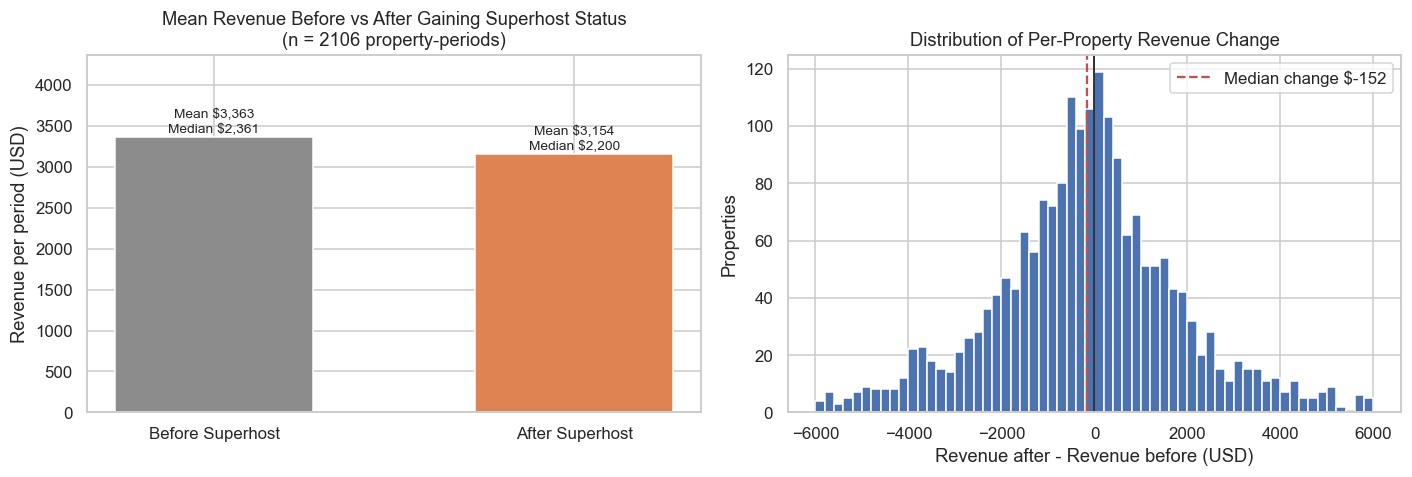

In [9]:
# The periods in which a property GAINED the badge. In these rows prev_revenue is
# the 'before' and revenue is the 'after' - same property, so it is its own control
gain = df[df['superhost_change_gain_superhost'] == 1]
print('Property-periods where Superhost status was gained: {}'.format(len(gain)))
print('Distinct properties in that set                   : {}'.format(gain['Airbnb Property ID'].nunique()))
print()

# A paired test needs both halves present, so drop rows missing either side
paired = gain.dropna(subset=['revenue', 'prev_revenue'])
print('Rows with BOTH before and after revenue recorded  : {}  ({} dropped: {} null prev_revenue,'
      ' {} null revenue)'.format(len(paired), len(gain) - len(paired),
                                 gain['prev_revenue'].isna().sum(), gain['revenue'].isna().sum()))
print('NOTE: a dropped row is usually a period with no bookings on one side, so this comparison')
print('      describes properties that were booked both before and after gaining the badge.')
print()

# Before/after summary table for the properties that gained the badge
before, after = paired['prev_revenue'], paired['revenue']
comp = pd.DataFrame({
    'Before Superhost (prev_revenue)': {'Mean': before.mean(), 'Median': before.median(),
                                        'Std dev': before.std(), 'Count': before.count()},
    'After Superhost (revenue)':       {'Mean': after.mean(), 'Median': after.median(),
                                        'Std dev': after.std(), 'Count': after.count()},
})
print('Revenue before vs after gaining Superhost status')
print(comp.round(2).to_string())
print()

# Each property's own revenue change, which is what a paired comparison needs
change = after - before
print('Per-property change in revenue (after - before)')
print('  Mean change   : ${:+,.2f}'.format(change.mean()))
print('  Median change : ${:+,.2f}'.format(change.median()))
print('  (those two null counts overlap - some rows are null on both sides)')
print('  Distinct properties behind the paired test: {}  (a few gained the badge more'.format(
    paired['Airbnb Property ID'].nunique()))
print('   than once, so they contribute more than one paired observation)')
print('  Properties whose revenue increased: {:.1%}'.format((change > 0).mean()))
print('  Properties whose revenue decreased: {:.1%}'.format((change < 0).mean()))
print('  Mean change as % of mean before   : {:+.1%}'.format(change.mean() / before.mean()))
print()

# ttest_REL (related), not ind: the two samples are the same properties measured
# twice, so the test looks at each property's own change
t, p = stats.ttest_rel(after, before)
print('Paired t-test (same property measured twice)')
print('  t-statistic = {:.3f}'.format(t))
print('  p-value     = {:.3e}{}'.format(p, '  (< 0.001)' if p < 0.001 else ''))
# Rank-based version of the paired test - a check that does not assume normality
w, pw = stats.wilcoxon(after, before)
print('Wilcoxon signed-rank (non-parametric check)')
print('  statistic = {:,.0f}   p-value = {:.3e}'.format(w, pw))

# Left: bar chart of mean revenue before vs after gaining the badge
# Right: histogram of per-property change, to show how wide the spread around it is
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
labels = ['Before Superhost', 'After Superhost']
means = [before.mean(), after.mean()]
medians = [before.median(), after.median()]
bars = axes[0].bar(labels, means, color=['#8C8C8C', '#DD8452'], width=0.55)
for bar, mn, mdn in zip(bars, means, medians):
    axes[0].text(bar.get_x() + bar.get_width() / 2, mn + 60,
                 'Mean ${:,.0f}\nMedian ${:,.0f}'.format(mn, mdn), ha='center', fontsize=9)
axes[0].set_title('Mean Revenue Before vs After Gaining Superhost Status\n(n = {} property-periods)'.format(len(paired)))
axes[0].set_ylabel('Revenue per period (USD)')
axes[0].set_ylim(0, max(means) * 1.30)

axes[1].hist(change, bins=60, range=(-6000, 6000), color='#4C72B0', edgecolor='white')
axes[1].axvline(0, color='black', lw=1)
axes[1].axvline(change.median(), color='#C44E52', ls='--',
                label='Median change ${:+,.0f}'.format(change.median()))
axes[1].set_title('Distribution of Per-Property Revenue Change')
axes[1].set_xlabel('Revenue after - Revenue before (USD)')
axes[1].set_ylabel('Properties'); axes[1].legend()
plt.tight_layout()
plt.show()

### Q7 follow-up — before/after alone cannot answer the question

The before/after comparison says revenue went down slightly after the badge was gained.
Taken at face value that would suggest becoming a Superhost hurts revenue, which is almost
certainly wrong. The problem is that "before" and "after" are different points in time, and
Question 4 showed bookings swing hard with the season. If badges tend to be awarded going into
a weaker quarter, the drop is the calendar, not the badge.

So we add a control group: properties that did not gain the badge, measured across the
same period transitions. If gainers and non-gainers move together, the change is market-wide.
The difference between the two changes (a difference-in-differences) is the part that can
plausibly be attributed to the badge.

Gainers: n = 2106    Control (did not gain): n = 22774

Mean revenue change (this period - previous period), by evaluation period
                      Gainers  Control  Difference  Gainer rows
superhost_period_all                                           
5.0                     132.0   -301.0       433.0           60
6.0                   -1518.0   -574.0      -944.0           86
7.0                     435.0    822.0      -387.0           73
8.0                    -550.0   -401.0      -148.0          118
9.0                     262.0    -10.0       272.0          129
10.0                  -1344.0  -1136.0      -208.0          110
11.0                    510.0   1221.0      -711.0          178
12.0                  -1328.0  -1053.0      -275.0          122
13.0                    218.0    320.0      -103.0           89
14.0                   -430.0   -722.0       292.0          151
15.0                    882.0   1012.0      -131.0          169
16.0                   -364.0   -932.0

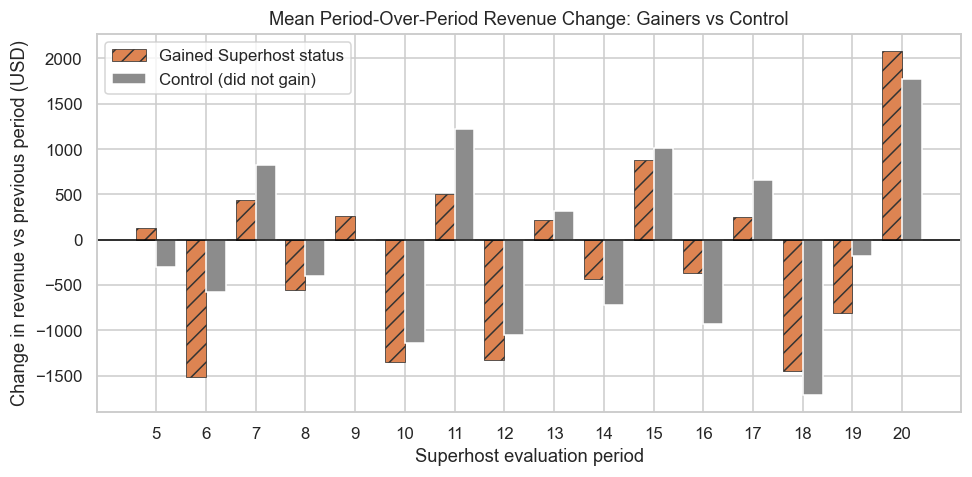

In [10]:
# Control group: properties that did NOT gain the badge, measured over the same
# period transitions. If both groups move together, the change is market-wide
control = df[df['superhost_change_gain_superhost'] == 0].dropna(subset=['revenue', 'prev_revenue'])
print('Gainers: n = {}    Control (did not gain): n = {}'.format(len(paired), len(control)))
print()

# Group a Series by another column's values: average change per evaluation period
gain_chg = (paired['revenue'] - paired['prev_revenue']).groupby(paired['superhost_period_all']).mean()
ctrl_chg = (control['revenue'] - control['prev_revenue']).groupby(control['superhost_period_all']).mean()
# Put both groups side by side, period by period
comp = pd.DataFrame({'Gainers': gain_chg, 'Control': ctrl_chg})
comp['Difference'] = comp['Gainers'] - comp['Control']
comp['Gainer rows'] = paired['superhost_period_all'].value_counts().sort_index()
print('Mean revenue change (this period - previous period), by evaluation period')
print(comp.round(0).to_string())
print()
print('-> The change swings between roughly -$1,500 and +$2,100 depending on the period.')
print('   Seasonality dwarfs anything the badge could be doing, and the control group swings')
print('   with the gainers almost period for period.')
print()

# Weight the control by the periods in which gains actually happened, so we compare
# like with like rather than letting the control's period mix do the work
# normalize=True turns counts into proportions - the share of badge-gains that
# happened in each period. These become the weights below
w = paired['superhost_period_all'].value_counts(normalize=True).sort_index()
# Weighted average: re-weight the control group so its mix of periods matches the
# gainers'. Without this we would be comparing different seasons to each other
ctrl_matched = (ctrl_chg.reindex(w.index) * w).sum()
gain_matched = (gain_chg.reindex(w.index) * w).sum()
print('Period-matched mean revenue change')
print('  Gainers                       : ${:+,.2f}'.format(gain_matched))
print('  Control, matched period mix   : ${:+,.2f}'.format(ctrl_matched))
print('  Difference-in-differences     : ${:+,.2f}'.format(gain_matched - ctrl_matched))
print()
print('Of the ${:+,.0f} raw before/after change, ${:+,.0f} is market-wide movement that the'.format(
    gain_matched, ctrl_matched))
print('control group experienced too, leaving ${:+,.0f} unexplained by seasonality.'.format(
    gain_matched - ctrl_matched))

# A point estimate on its own overstates what we know. Standard error of the weighted
# difference = gainer sampling variance + the period-weighted control variance.
_gd = (paired['revenue'] - paired['prev_revenue'])
_cd = (control['revenue'] - control['prev_revenue'])
_cvar = _cd.groupby(control['superhost_period_all']).var().reindex(w.index)
_cn = _cd.groupby(control['superhost_period_all']).size().reindex(w.index)
did = gain_matched - ctrl_matched
se = np.sqrt(_gd.var() / len(_gd) + ((w ** 2) * (_cvar / _cn)).sum())
print()
print('  Standard error                : ${:,.1f}'.format(se))
print('  95% confidence interval       : [${:+,.0f}, ${:+,.0f}]'.format(
    did - 1.96 * se, did + 1.96 * se))
print('  -> The interval CONTAINS ZERO. The difference-in-differences is not')
print('     distinguishable from zero, so the honest statement is "no measurable badge')
print('     effect in either direction" - not "the badge costs $148 per period".')

# Grouped bar chart of period-over-period revenue change, gainers vs control,
# to show the two groups rising and falling together
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(comp))
ax.bar(x - 0.2, comp['Gainers'], width=0.4, label='Gained Superhost status', color='#DD8452',
       hatch='//', edgecolor='#333333', linewidth=0.5)   # greyscale safety
ax.bar(x + 0.2, comp['Control'], width=0.4, label='Control (did not gain)', color='#8C8C8C')
ax.axhline(0, color='black', lw=1)
ax.set_xticks(x)
ax.set_xticklabels([int(p) for p in comp.index])
ax.set_title('Mean Period-Over-Period Revenue Change: Gainers vs Control')
ax.set_xlabel('Superhost evaluation period')
ax.set_ylabel('Change in revenue vs previous period (USD)')
ax.legend()
plt.tight_layout()
plt.show()

### Findings — Question 7

Does revenue increase after gaining Superhost status? On this evidence, no. The honest
answer is that the question as posed cannot be answered by a before/after bar chart.

Of 3,428 property-periods where the badge was gained (3,036 distinct properties), 2,106 have
revenue recorded on both sides. For those:

| | Before (`prev_revenue`) | After (`revenue`) |
|---|---|---|
| Mean | $3,362.58 | $3,154.07 |
| Median | $2,361.00 | $2,200.00 |

Revenue fell by a mean of -$208.51 and a median of -$152.50; only 45.8% of
properties improved. The paired t-test (t = -2.77, p = 0.006) and Wilcoxon (p = 2e-05) both say
the decline is larger than chance.

But the control group shows most of that decline is not about the badge. Question 4
established that bookings swing seasonally, and "before" and "after" are different quarters. When
we measure the same period-over-period change for properties that did not gain the badge, they
move almost in lockstep — both groups swing between roughly -$1,500 and +$2,100 depending on
which period transition you look at. Matching the control to the periods in which gains actually
occurred:

- Gainers: -$208 per period
- Control, same period mix: -$60
- Difference-in-differences: -$148

So of the raw $208 decline, roughly $60 is market-wide seasonal movement the control
experienced too, leaving about $148 unexplained by seasonality. That residual should not be
reported as an effect: its 95% confidence interval is **[−$307, +$10]**, which contains zero.
Once seasonality is absorbed there is no measurable badge effect in either direction.

Our conclusion: There is no evidence that gaining Superhost status raises revenue in the
period immediately after it is awarded, and the small apparent decline is mostly seasonality.
The most likely explanation for the residual is regression to the mean: the badge is awarded
following an unusually strong stretch, so the "before" figure is measured at a local peak and
almost has to fall back. This does not contradict Question 6 — Superhosts really do earn more
than non-Superhosts. It says the badge is a marker of properties that were already performing
well, not a switch that lifts revenue the moment it is granted.

There is a further reason to read this as "no measurable effect" rather than as a precise zero:
the measurement windows overlap. `available_days` — the exposure window a period measures, and the
denominator of `occupancy_rate` — has a median of **171 days**, while consecutive evaluation periods
are about **91 days** apart, so a property's "before" and "after" share roughly **47%** of their
measurement window. Any true effect is mechanically attenuated
toward zero by that overlap.

Methodological note: We report the mean of the per-property change, not the difference of two
group means, because the same property is measured twice. We also dropped 1,322 rows missing one
side, so this describes properties that were booked both before and after — properties that went
from idle to booked (or the reverse) are excluded, which is exactly where a badge effect might
otherwise show up.

The answer for management is a negative one, and worth stating plainly: gaining the badge does not
raise revenue in the period after it is awarded. Once a matched control absorbs the seasonality,
the difference-in-differences is -$148 on a $3,363 base. Superhost status should be treated as a
signal that identifies listings already performing well, not as an intervention that lifts revenue
when extended to more hosts. A policy of awarding more badges in order to grow revenue would rest
on a correlation this analysis does not support.

---
# Question 8 — Revenue trend across evaluation periods

> Use a line chart to illustrate the trend in revenue over multiple evaluation periods for
> Superhosts. How does Superhost status impact revenue over time?

Chart choice and why: Mean revenue by `superhost_period_all`, with both groups on one set of
axes. A Superhost line on its own cannot distinguish "Superhosts are growing" from "the whole
Dallas market is growing" — the non-Superhost line is the control.

Given the skew found in Question 6 we plot the median as well as the mean, and print the row
count per period so thin periods can be flagged.

Mean / median revenue and row count by evaluation period
                                          mean  median  count
superhost_period_all Superhost status                        
5.0                  Non-Superhost     2448.19  1618.0    593
                     Superhost         3057.90  2546.0    239
6.0                  Non-Superhost     2269.10  1346.0    605
                     Superhost         2476.95  1779.0    301
7.0                  Non-Superhost     3149.52  1950.0    597
                     Superhost         3265.21  2400.0    313
8.0                  Non-Superhost     2780.24  1870.0    718
                     Superhost         3000.27  1949.5    426
9.0                  Non-Superhost     2814.00  1945.0    811
                     Superhost         3551.95  2571.0    573
10.0                 Non-Superhost     2194.88  1395.0    913
                     Superhost         2794.35  2070.0    723
11.0                 Non-Superhost     3731.82  2059.5    952
             

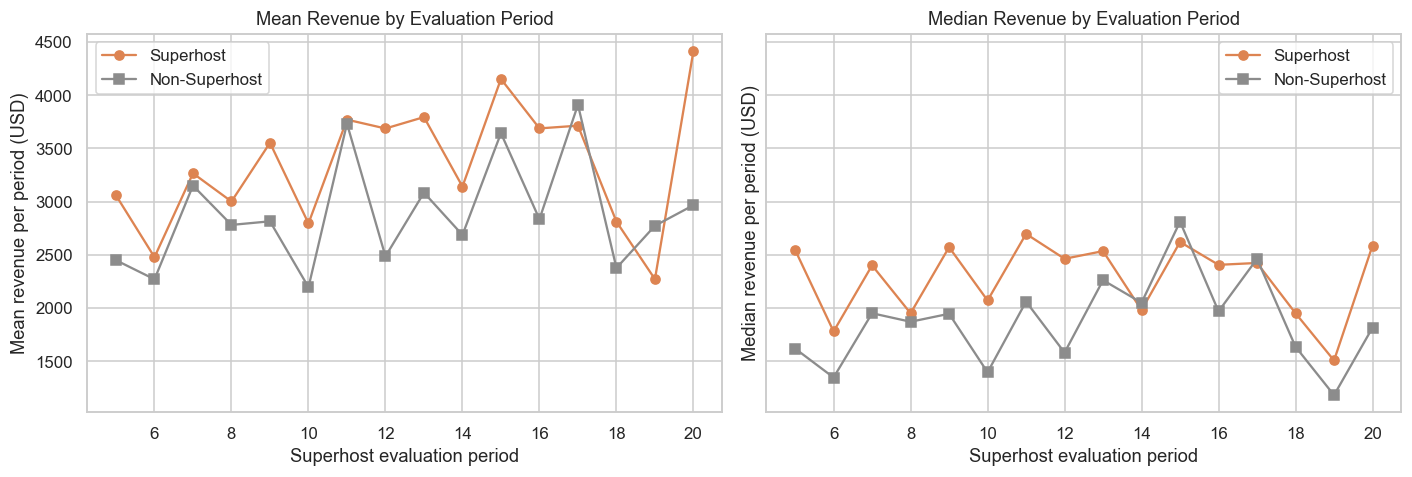

In [11]:
rev = df.dropna(subset=['revenue'])
# Grouping by two columns gives a two-level index; .agg runs several statistics at once
g = (rev.groupby(['superhost_period_all', 'Superhost status'])['revenue']
       .agg(['mean', 'median', 'count']).round(2))
print('Mean / median revenue and row count by evaluation period')
print(g.to_string())
print()

# unstack() lifts the inner index level (Superhost status) into columns, which is
# the shape matplotlib needs: one column per line on the chart
piv_mean = g['mean'].unstack()
piv_med = g['median'].unstack()
piv_n = g['count'].unstack()

# .any(axis=1) flags a period if EITHER group is thin (vs .all which needs both)
# Flag any period with thin data before we read trends off the chart
thin = piv_n[(piv_n < 100).any(axis=1)]
if len(thin):
    print('Periods with fewer than 100 rows in a group (treat with caution):')
    print(thin.astype(int).to_string())
else:
    print('No period has fewer than 100 rows in either group.')
print()

# Growth from the first period to the last, for each group
first, last = piv_mean.index.min(), piv_mean.index.max()
for lab in ['Superhost', 'Non-Superhost']:
    print('{:<14} mean revenue: period {:.0f} = ${:,.0f}  ->  period {:.0f} = ${:,.0f}  ({:+.1%})'.format(
        lab, first, piv_mean.loc[first, lab], last, piv_mean.loc[last, lab],
        piv_mean.loc[last, lab] / piv_mean.loc[first, lab] - 1))
print()
# The Superhost revenue premium in each period
gap = piv_mean['Superhost'] - piv_mean['Non-Superhost']
print('Superhost revenue premium (mean gap, USD per period)')
print(gap.round(0).to_string())
print('\nAverage premium across periods: ${:,.0f}'.format(gap.mean()))

# Line chart of revenue by period with one line per group, drawn twice:
# mean on the left, median on the right because revenue is so skewed
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True, sharey=True)
for ax, piv, name in [(axes[0], piv_mean, 'Mean'), (axes[1], piv_med, 'Median')]:
    for lab, colr, mk in [('Superhost', '#DD8452', 'o'), ('Non-Superhost', '#8C8C8C', 's')]:
        ax.plot(piv.index, piv[lab], marker=mk, color=colr, label=lab)
    ax.set_title('{} Revenue by Evaluation Period'.format(name))
    ax.set_xlabel('Superhost evaluation period')
    ax.set_ylabel('{} revenue per period (USD)'.format(name))
    ax.legend(title='')
plt.tight_layout()
plt.show()

### Findings — Question 8

Why both groups on one chart? A Superhost line alone cannot distinguish "Superhosts are
growing" from "Dallas is growing." The non-Superhost line is the control, and we plot the median
alongside the mean because Question 6 showed how skewed revenue is.

Superhosts hold a persistent premium. Mean revenue is higher for Superhosts in 14 of the 16
evaluation periods, averaging +$465 across the 16 periods. The exceptions are periods 17
(-$196) and 19 (-$502). The premium is not stable — it ranges from $38 (period 11) to $1,449
(period 20) — which fits the seasonal swings found in Question 4 rather than any steady trend.

The premium is persistent but shows no trend. It is tempting to read growth into the two
endpoints — mean Superhost revenue runs $3,058 in period 5 against $4,415 in period 20 (+44.4%)
versus $2,448 to $2,966 (+21.1%) for non-Superhosts — but that comparison does not survive
scrutiny, for three reasons. Regressing the premium on period number gives a slope of **+$6 per
period (p = 0.82)**, indistinguishable from flat. The **median** premium moves the other way,
from $928 in period 5 to $771 in period 20. And periods are quarterly, so period 5 (Aug–Sep 2016)
and period 20 (May–Jun 2020) are *different seasons* — the exact error Questions 4 and 7 were
careful to avoid. Comparing like seasons flips the result — with one caveat that only became
visible later: period 17 is where Questions 13 and 15 find a suspected measurement-regime change
(the market-wide median listed rate roughly halves and stays there), so this comparison is
directional rather than precise, and both of the negative-premium periods below (17 and 19) sit
after that break. Period 5 → 17, both Aug–Sep, gives
Superhosts +21.4% against non-Superhosts +59.7%. Period 20 is also May–June 2020, so the
endpoint sits inside the COVID shock Question 4 identified.

What the data does support: Superhosts are persistently ahead, and there is no evidence the lead
is growing. Both lines share the same saw-tooth shape, confirming that period-to-period movement
is market seasonality affecting everyone.

How to state the impact honestly. Reading this as "Superhost status increases revenue over
time" would overstate it, and Question 7 is the reason: when we isolated properties at the moment
they gained the badge and compared them against a matched control, the effect was slightly
negative. The two results are consistent if Superhost status is largely a marker of
consistently strong properties rather than a cause of revenue growth — the badge tracks
listings that were already outperforming, and those listings continue to outperform. Selection is
doing more work here than treatment.

Sample sizes support the comparison throughout: no period has fewer than 100 rows in either
group, though early periods are thinner (239 Superhost rows in period 5 vs 1,081 in period 20),
so the early points carry more sampling noise than the later ones.

The premium is persistent but flat, averaging +$465 a period with a slope of +$6 per period
(p = 0.82). Read alongside Question 7, that points to selection rather than effect: the badge
tracks consistently strong listings rather than creating them. The spending implication is that
identifying and supporting listings before they qualify is more likely to move revenue than
expanding badge eligibility after the fact, which is where Question 7 landed from the opposite
direction.

---
# Question 9 — Scatter plot of rating vs revenue

> Create a scatter plot to examine the relationship between rating_ave_pastYear and revenue.
> What correlation exists between ratings and revenue?

Approach: the question names the chart. With roughly 27,000 points a plain scatter is a solid
block of ink, so we use small markers with transparency and overlay a line of mean revenue
within rating bins. Ratings cluster hard near 5, so we print how concentrated they are before
reporting the correlation, and we band the ratings because a single coefficient cannot show a
relationship that bends.

Rows used: 26,686 of 48,711 (22,025 dropped for a null rating or revenue)
Rating: median 4.82, standard deviation 0.246
Share at 4.5+: 90.1%   at 4.8+: 54.3%   exactly 5.0: 17.0%

Pearson  r   = +0.078 (p = 5.0e-37), r-squared = 0.0060
Spearman rho = +0.035 (p = 1.5e-08)

Revenue by rating band
                     rows  mean_revenue  median_revenue  median_reviews
rating_ave_pastYear                                                    
<=4.0                 403        1385.0           946.0             3.0
4.0-4.4              1341        2355.0          1457.0            62.0
4.4-4.6              3077        2594.0          1800.0            62.0
4.6-4.8              7669        2981.0          2156.0           143.0
4.8-4.99             9623        3344.0          2228.0            62.0
5.0 exactly          4573        2921.0          1602.0             7.0


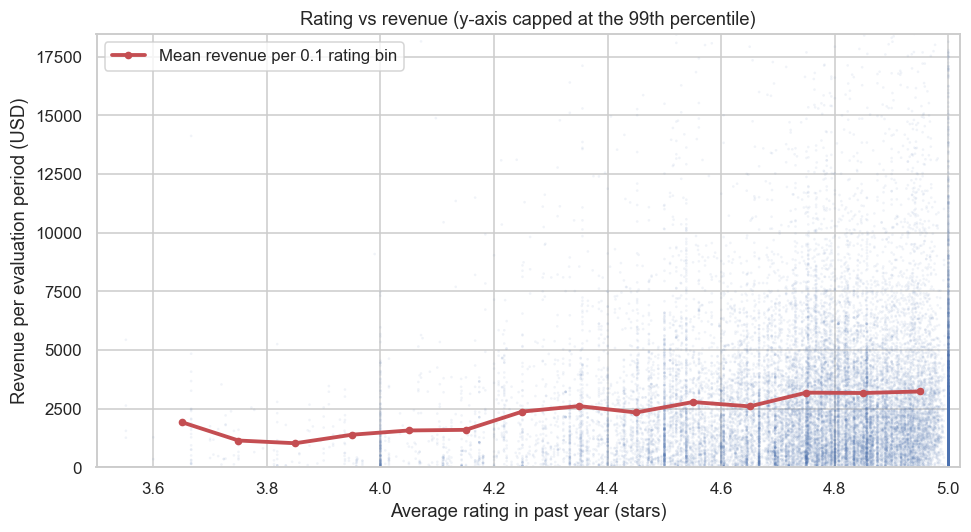

In [12]:
# Q9: is a higher rating associated with higher revenue?
q9 = df.dropna(subset=['rating_ave_pastYear', 'revenue'])
print('Rows used: {:,} of {:,} ({:,} dropped for a null rating or revenue)'.format(
    len(q9), len(df), len(df) - len(q9)))

# How concentrated are ratings? This limits how much correlation is even possible.
r = q9['rating_ave_pastYear']
print('Rating: median {:.2f}, standard deviation {:.3f}'.format(r.median(), r.std()))
print('Share at 4.5+: {:.1%}   at 4.8+: {:.1%}   exactly 5.0: {:.1%}'.format(
    (r >= 4.5).mean(), (r >= 4.8).mean(), (r == 5.0).mean()))
print()

# Both coefficients: Pearson measures a straight-line fit, Spearman measures rank order
pear, p_pear = stats.pearsonr(q9['rating_ave_pastYear'], q9['revenue'])
spear, p_spear = stats.spearmanr(q9['rating_ave_pastYear'], q9['revenue'])
print('Pearson  r   = {:+.3f} (p = {:.1e}), r-squared = {:.4f}'.format(pear, p_pear, pear**2))
print('Spearman rho = {:+.3f} (p = {:.1e})'.format(spear, p_spear))
print()

# Banded view. The review-count column explains what happens at the top end.
bands = pd.cut(q9['rating_ave_pastYear'], [0, 4.0, 4.4, 4.6, 4.8, 4.99, 5.0],
               labels=['<=4.0', '4.0-4.4', '4.4-4.6', '4.6-4.8', '4.8-4.99', '5.0 exactly'])
tbl = q9.groupby(bands, observed=True).agg(
    rows=('revenue', 'size'), mean_revenue=('revenue', 'mean'),
    median_revenue=('revenue', 'median'), median_reviews=('numReviews_pastYear', 'median'))
print('Revenue by rating band')
print(tbl.round(0).to_string())

# Heavy transparency, or 26,686 points print as one solid block of ink
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(q9['rating_ave_pastYear'], q9['revenue'], s=3, alpha=0.08,
           color='#4C72B0', edgecolors='none')
# Mean revenue inside each 0.1-wide rating bin, drawn only where a bin holds 30+ rows
bins = np.arange(3.5, 5.05, 0.1)
mids, means = [], []
for lo, hi in zip(bins[:-1], bins[1:]):
    s = q9.loc[q9['rating_ave_pastYear'].between(lo, hi), 'revenue']
    if len(s) >= 30:
        mids.append((lo + hi) / 2); means.append(s.mean())
ax.plot(mids, means, color='#C44E52', lw=2.5, marker='o', ms=4,
        label='Mean revenue per 0.1 rating bin')
# Cap the y-axis at the 99th percentile so the body of the data stays visible
ax.set_xlim(3.5, 5.02)
ax.set_ylim(0, q9['revenue'].quantile(0.99))
ax.set_xlabel('Average rating in past year (stars)')
ax.set_ylabel('Revenue per evaluation period (USD)')
ax.set_title('Rating vs revenue (y-axis capped at the 99th percentile)')
ax.legend()
plt.tight_layout()
plt.show()

### Findings — Question 9

The correlation is positive but very weak. Across the 26,686 property-periods that have both a
rating and a revenue figure, Pearson r = +0.078 and Spearman rho = +0.035. An r-squared of 0.0060
means rating explains six tenths of one percent of the variation in revenue. The p-values are tiny
only because the sample is large, so the honest summary is that ratings and revenue are close to
unrelated in this data.

Part of the reason is that there is almost no variation in ratings to work with. The median rating
is 4.82, the standard deviation is 0.246 on a five point scale, 90.1% of rows sit at 4.5 or above
and 17.0% are exactly 5.0. When nearly every listing is rated highly, there is very little spread
in the x variable for revenue to track, so a near zero correlation partly reflects how compressed
Airbnb ratings are rather than proving that guest satisfaction is irrelevant.

The banded table shows something a single coefficient cannot, which is that the relationship
bends. Mean revenue climbs steadily from $1,385 below 4.0 to $2,981 in the 4.6 to 4.8 band and
$3,344 in the 4.8 to 4.99 band, and then falls to $2,921 at exactly 5.0. Median revenue drops
harder, from $2,228 to $1,602.

The review counts explain that drop. Listings rated exactly 5.0 have a median of 7 reviews, against
143 in the 4.6 to 4.8 band. A perfect score is usually a thin evidence score, earned by a new or
lightly booked listing with too few reviews for any of them to be below five stars, rather than a
sign of a better property. The same thing happens at the bottom, where the under 4.0 band has a
median of 3 reviews. So the usable pattern is a rise up to roughly 4.8 and then a plateau.

Pushing an already strong listing from 4.8 toward 5.0 has no measurable revenue payoff, so host
coaching and any incentive spending is better aimed at the listings below 4.5, where the gap to the
next band is worth roughly $1,600 in mean revenue. Rating is a standard to maintain rather than a
lever to grow. This is correlation only, and the direction is ambiguous, since more bookings
generate more reviews and more reviews move the rating.

---
# Question 10 — Listing type composition of Superhost bookings

> What listing type dominates bookings for Superhosts? Decide on the best way to visualize the
> composition of bookings by Listing Type and explain your conclusions.

Approach: the question says "dominates bookings", so the measure is total booked nights by
listing type rather than a count of listings, since a type can have many listings but few booked
nights. We use a grouped horizontal bar chart of each type's share, Superhosts against
non-Superhosts, because the comparison is the point and a pie chart cannot show two groups at
once. We also report each type's share of revenue, because nights and dollars do not split the
same way.

Rows used: 48,711 of 48,711 (none dropped)

Superhost: composition by listing type
   Listing Type  listings  nights pct_nights pct_revenue rev_per_night
Entire home/apt      3210 269,461      74.5%       89.1%       $145.61
   Private room       861  79,877      22.1%        9.9%        $54.67
    Shared room       107  11,331       3.1%        0.6%        $24.95
     Hotel room        11   1,090       0.3%        0.3%       $123.64

Non-Superhost: composition by listing type
   Listing Type  listings  nights pct_nights pct_revenue rev_per_night
Entire home/apt      6171 369,306      82.2%       93.1%       $140.75
   Private room      1758  70,364      15.7%        6.2%        $49.23
    Shared room       271   8,694       1.9%        0.4%        $28.16
     Hotel room        15   1,020       0.2%        0.2%       $112.14

Share of booked nights, side by side (%)
Superhost status  Non-Superhost  Superhost
Listing Type                              
Hotel room                  0.2    

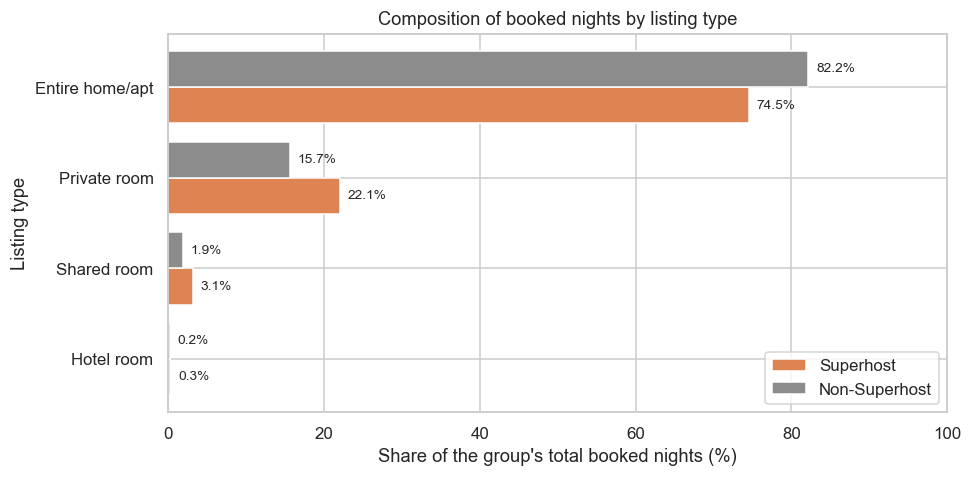

In [13]:
# Q10: which listing type accounts for most Superhost booked nights?
# booked_days_z and revenue_z count an unbooked period as 0 rather than dropping it,
# so all 48,711 property-periods are represented.
comp = (df.groupby(['Superhost status', 'Listing Type'])
          .agg(nights=('booked_days_z', 'sum'), revenue=('revenue_z', 'sum'),
               listings=('Airbnb Property ID', 'nunique')).reset_index())
# Shares are computed within each group, so each group's column sums to 100%
comp['pct_nights'] = comp.groupby('Superhost status')['nights'].transform(lambda s: 100*s/s.sum())
comp['pct_revenue'] = comp.groupby('Superhost status')['revenue'].transform(lambda s: 100*s/s.sum())
comp['rev_per_night'] = comp['revenue'] / comp['nights']

print('Rows used: {:,} of {:,} (none dropped)'.format(len(df), len(df)))
print()
# Full composition for each group, nights and dollars side by side
for grp in ['Superhost', 'Non-Superhost']:
    t = comp[comp['Superhost status'] == grp].sort_values('pct_nights', ascending=False)
    print('{}: composition by listing type'.format(grp))
    print(t[['Listing Type', 'listings', 'nights', 'pct_nights', 'pct_revenue', 'rev_per_night']]
          .to_string(index=False, formatters={
              'nights': '{:,.0f}'.format, 'pct_nights': '{:.1f}%'.format,
              'pct_revenue': '{:.1f}%'.format, 'rev_per_night': '${:.2f}'.format}))
    print()

# Reshape to one row per listing type and one column per group, ready for the chart
piv = comp.pivot(index='Listing Type', columns='Superhost status',
                 values='pct_nights').sort_values('Superhost')
print('Share of booked nights, side by side (%)')
print(piv.round(1).to_string())

# Grouped horizontal bars, so the two groups can be compared type by type
fig, ax = plt.subplots(figsize=(9, 4.5))
y = np.arange(len(piv))
ax.barh(y - 0.2, piv['Superhost'], height=0.4, color='#DD8452', label='Superhost')
ax.barh(y + 0.2, piv['Non-Superhost'], height=0.4, color='#8C8C8C', label='Non-Superhost')
# Label each bar so the chart can be read without going back to the table
for i, (sh, non) in enumerate(zip(piv['Superhost'], piv['Non-Superhost'])):
    ax.text(sh + 1, i - 0.2, '{:.1f}%'.format(sh), va='center', fontsize=9)
    ax.text(non + 1, i + 0.2, '{:.1f}%'.format(non), va='center', fontsize=9)
ax.set_yticks(y); ax.set_yticklabels(piv.index)
ax.set_ylabel('Listing type')
ax.set_xlabel("Share of the group's total booked nights (%)")
ax.set_title('Composition of booked nights by listing type')
ax.set_xlim(0, 100); ax.legend()
plt.tight_layout()
plt.show()

### Findings — Question 10

Entire homes dominate Superhost bookings, taking 74.5% of all Superhost booked nights, against
22.1% for private rooms, 3.1% for shared rooms and 0.3% for hotel rooms.

The revenue split is not the same, and the difference matters. The same Superhost listings produce
89.1% of their revenue from entire homes and only 9.9% from private rooms. Private and shared
rooms together supply a quarter of the nights Superhosts sell but about a tenth of the dollars,
because a Superhost entire home earns $145.61 per booked night while a private room earns $54.67
and a shared room $24.95. A manager planning capacity from the nights view and a manager planning
from the revenue view would rank these segments differently.

The obvious explanation, that Superhosts simply list more entire homes, is not what the data shows.
Non-Superhosts are actually more concentrated in entire homes than Superhosts are, 82.2% of their
booked nights against 74.5%. Relative to non-Superhosts, Superhost bookings are tilted more toward
private rooms, 22.1% against 15.7%, which is the opposite of the intuitive story.

Two slices should not be over read. Hotel room covers only 11 Superhost listings and 1,090 booked
nights, and shared rooms rest on 107 Superhost listings, so their percentages move easily.

The gap between the nights ledger and the revenue ledger is the thing to act on. Airbnb's Dallas
team should decide which of the two the Superhost program is measured against before setting
targets, because room-share inventory looks meaningful counted in nights and marginal counted in
dollars. Entire homes are where the money is and should carry the pricing work, while private and
shared rooms are better managed on occupancy. This compares two self-selected groups and carries no
causal content, since the badge is awarded partly on booking behavior.

---
# Question 11 — Correlation matrix heatmap

> Use a correlation matrix heatmap to explore the relationships between revenue, occupancy_rate,
> rating_ave_pastYear, and numReviews_pastYear. Which variables show the strongest correlations,
> and how might these impact business decisions for hosts?

Approach: the question names the chart and the four columns. We show Pearson and Spearman side
by side, because revenue and review counts are heavily skewed (Question 6) and the two
coefficients rank the variables differently. Note that revenue and occupancy_rate are linked by
arithmetic rather than behavior, since revenue is roughly nights booked times price and occupancy
is nights booked over available days, so we report that cell and then set it aside.

Rows used: 26,686 of 48,711 (22,025 dropped for a null on any of the four)

Pearson (linear)
                     revenue  occupancy_rate  rating_ave_pastYear  numReviews_pastYear
revenue                1.000           0.223                0.078                0.072
occupancy_rate         0.223           1.000                0.050               -0.026
rating_ave_pastYear    0.078           0.050                1.000               -0.202
numReviews_pastYear    0.072          -0.026               -0.202                1.000

Spearman (rank)
                     revenue  occupancy_rate  rating_ave_pastYear  numReviews_pastYear
revenue                1.000           0.544                0.035                0.214
occupancy_rate         0.544           1.000                0.039                0.106
rating_ave_pastYear    0.035           0.039                1.000               -0.364
numReviews_pastYear    0.214           0.106               -0.364                1.000

The six pairs, rank

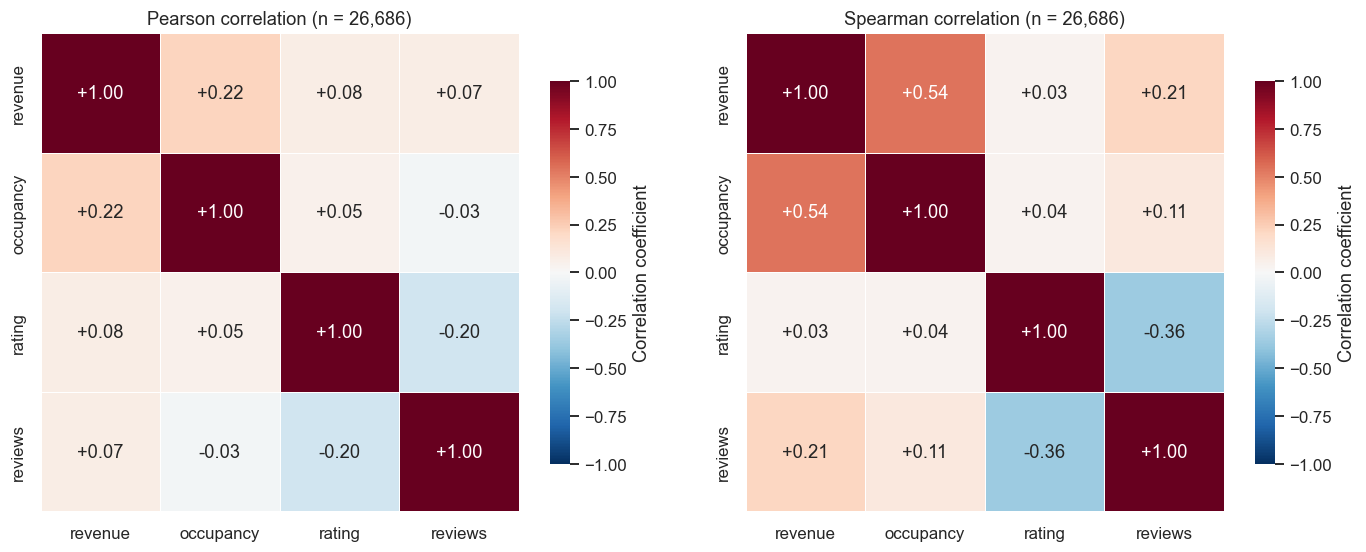

In [14]:
# Q11: correlations among the four columns the question names.
cols = ['revenue', 'occupancy_rate', 'rating_ave_pastYear', 'numReviews_pastYear']
q11 = df[cols].dropna()   # complete cases, so every cell rests on the same rows
print('Rows used: {:,} of {:,} ({:,} dropped for a null on any of the four)'.format(
    len(q11), len(df), len(df) - len(q11)))
print()

# Pearson for linear association, Spearman for rank, since revenue and review
# counts are heavily skewed and the two disagree here
pearson, spearman = q11.corr(), q11.corr(method='spearman')
print('Pearson (linear)')
print(pearson.round(3).to_string())
print()
print('Spearman (rank)')
print(spearman.round(3).to_string())
print()

# Pull out the six unique pairs so the ranking is explicit rather than read off colors
pairs = []
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        pairs.append({'pair': '{} ~ {}'.format(cols[i], cols[j]),
                      'pearson': pearson.iloc[i, j], 'spearman': spearman.iloc[i, j]})
pairs = pd.DataFrame(pairs).sort_values('spearman', key=abs, ascending=False)
print('The six pairs, ranked by absolute Spearman')
print(pairs.round(3).to_string(index=False))

# Short labels, because the full column names do not fit on a heatmap axis
short = ['revenue', 'occupancy', 'rating', 'reviews']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
# Same -1 to +1 scale on both panels so they can be compared directly
for ax, m, name in [(axes[0], pearson, 'Pearson'), (axes[1], spearman, 'Spearman')]:
    sns.heatmap(m, annot=True, fmt='+.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                square=True, linewidths=0.5, cbar_kws={'shrink': 0.8, 'label': 'Correlation coefficient'},
                xticklabels=short, yticklabels=short, ax=ax)
    ax.set_title('{} correlation (n = {:,})'.format(name, len(q11)))
plt.tight_layout()
plt.show()

### Findings — Question 11

The largest coefficient in the matrix is not a finding. Revenue and occupancy_rate correlate at
Pearson +0.223 and Spearman +0.544, but the two are linked by arithmetic rather than behavior,
because revenue is roughly nights booked times price and occupancy is nights booked over available
days. They share a term by construction, so the cell is reported and then set aside.

The strongest genuine relationship is negative. Rating and review count correlate at Spearman
-0.364 and Pearson -0.202, meaning listings with more reviews tend to have lower average scores.
Question 9 showed the mechanism, which is that a small number of reviews makes a perfect score easy
to hold. The practical reading is that the two review side metrics pull against each other and
cannot both be maximized.

The two coefficients disagree enough to change the answer. Revenue against review count moves from
Pearson +0.072 to Spearman +0.214, and occupancy against review count flips sign, from -0.026 to
+0.106. This happens because revenue and review counts are heavily skewed, so Pearson is pulled by
a few extreme listings while Spearman describes the typical one. On Spearman the ranking of revenue
drivers is occupancy, then review volume, then rating. On Pearson it is occupancy, then rating,
then review volume. Anyone quoting one matrix alone would rank the two review metrics differently.

Rating is the weakest link to revenue on either measure, at +0.078 Pearson and +0.035 Spearman.

For a host deciding where to spend effort, occupancy and review volume are the two metrics that
track revenue, and average rating is not. That argues for prompting guests to leave any review
rather than protecting a perfect score, and for accepting the small rating cost that comes with
higher volume. These are cross sectional associations on panel data, where one property contributes
many of the 26,686 rows, so the observations are not independent and none of this establishes
cause.

---
# Question 12 — Neighborhoods with highest revenue and occupancy for Superhosts

> Which neighborhoods show the highest revenue and occupancy rates for Superhosts? Determine the
> best way to visualize and analyze this information.

Approach: two ranked horizontal bar charts, one per measure, sharing the same neighborhood order
so it is possible to see at a glance whether the same places top both. We rank on the median
rather than the mean, because Question 6 showed how skewed revenue is and a few luxury listings
would otherwise decide the ranking, and we require at least 20 distinct properties rather than 30
rows, because in panel data a handful of listings observed many times would clear a row threshold.

Superhost rows: 12,228 of 15,920, after dropping null neighborhood, revenue or occupancy
17 named neighborhoods, 11 kept with 20+ distinct properties, 6 dropped

Superhost performance by neighborhood, sorted by median revenue
                         properties  rows  median_revenue  mean_revenue  median_occupancy
Neighborhood                                                                             
Central Dallas                 1899  6192          2693.0      3724.109             0.179
Oak Lawn                        338  1189          2400.0      3815.702             0.182
Lakewood                         22   103          2375.0      3307.816             0.221
White Rock East                  22    80          2221.5      2901.638             0.167
Northwest Dallas                184   623          2005.0      3104.067             0.186
Lake Highlands                   78   283          1948.0      6087.696             0.148
Southwest Dallas                453  2012          183

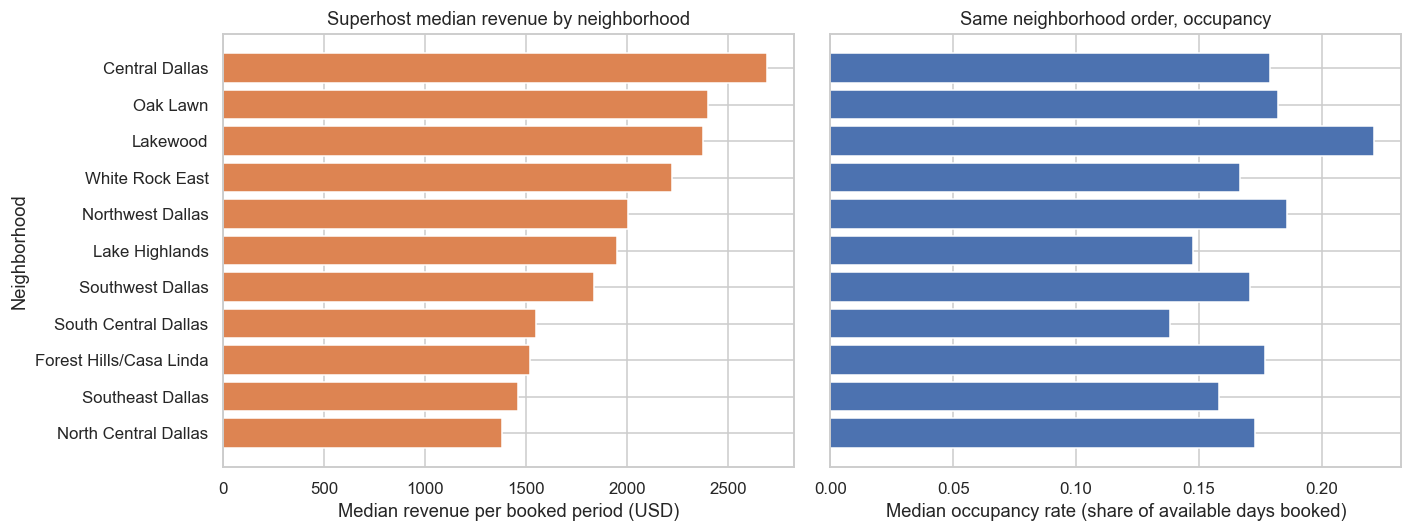

In [15]:
# Q12: Superhost revenue and occupancy by neighborhood.
sh = df[df['Superhost'] == 1].dropna(subset=['Neighborhood', 'revenue', 'occupancy_rate'])
print('Superhost rows: {:,} of {:,}, after dropping null neighborhood, revenue or occupancy'.format(
    len(sh), int((df['Superhost'] == 1).sum())))

# One row per neighborhood. The mean is kept only to show why we rank on the median
g = sh.groupby('Neighborhood').agg(
    properties=('Airbnb Property ID', 'nunique'), rows=('revenue', 'size'),
    median_revenue=('revenue', 'median'), mean_revenue=('revenue', 'mean'),
    median_occupancy=('occupancy_rate', 'median'))
# 20 distinct properties, not 20 rows: in panel data one listing supplies many rows
keep = g[g['properties'] >= 20].sort_values('median_revenue', ascending=False)
dropped = g[g['properties'] < 20]
print('{} named neighborhoods, {} kept with 20+ distinct properties, {} dropped'.format(
    len(g), len(keep), len(dropped)))
print()
print('Superhost performance by neighborhood, sorted by median revenue')
print(keep.round(3).to_string())
print()
# The two spreads are the point: revenue separates neighborhoods, occupancy barely does
print('Median revenue spans ${:,.0f} to ${:,.0f} ({:.2f}x)'.format(
    keep['median_revenue'].min(), keep['median_revenue'].max(),
    keep['median_revenue'].max() / keep['median_revenue'].min()))
print('Median occupancy spans {:.3f} to {:.3f} ({:.2f}x)'.format(
    keep['median_occupancy'].min(), keep['median_occupancy'].max(),
    keep['median_occupancy'].max() / keep['median_occupancy'].min()))
print('Highest median revenue  : {} (${:,.0f})'.format(
    keep.index[0], keep['median_revenue'].iloc[0]))
print('Highest median occupancy: {} ({:.3f})'.format(
    keep['median_occupancy'].idxmax(), keep['median_occupancy'].max()))
print('Rank correlation between the two rankings: rho = {:+.3f}'.format(
    stats.spearmanr(keep['median_revenue'], keep['median_occupancy'])[0]))
# What the ranking would look like on means, which is why we did not use them
print('Mean-revenue leader would be {} (${:,.0f} mean vs ${:,.0f} median)'.format(
    keep['mean_revenue'].idxmax(), keep['mean_revenue'].max(),
    keep.loc[keep['mean_revenue'].idxmax(), 'median_revenue']))

# Reverse so the highest median revenue sits at the top of the chart
order = keep.index[::-1]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(range(len(order)), keep.loc[order, 'median_revenue'], color='#DD8452')
axes[0].set_yticks(range(len(order))); axes[0].set_yticklabels(order)
axes[0].set_ylabel('Neighborhood')
axes[0].set_xlabel('Median revenue per booked period (USD)')
axes[0].set_title('Superhost median revenue by neighborhood')
# Second panel keeps the first panel's order, so a row is the same neighborhood in both
axes[1].barh(range(len(order)), keep.loc[order, 'median_occupancy'], color='#4C72B0')
axes[1].set_yticks(range(len(order))); axes[1].set_yticklabels([])
axes[1].set_xlabel('Median occupancy rate (share of available days booked)')
axes[1].set_title('Same neighborhood order, occupancy')
plt.tight_layout()
plt.show()

### Findings — Question 12

On the 11 neighborhoods with at least 20 distinct Superhost properties, Central Dallas has the
highest median Superhost revenue at $2,693 per booked period, followed by Oak Lawn at $2,400 and
Lakewood at $2,375. Lakewood has the highest median occupancy at 0.221, followed by Northwest
Dallas at 0.186 and Oak Lawn at 0.182.

The two rankings do not line up. The rank correlation between them is rho = +0.518, positive but
far from a match on only 11 neighborhoods. Lakewood is first on occupancy but third on revenue,
Lake Highlands is sixth on revenue and tenth of eleven on occupancy, and North Central Dallas is
sixth on occupancy but last on revenue.

The ranges are the more useful half of the answer. Median revenue spans $1,382 to $2,693 across
the eleven neighborhoods, a spread of 1.95x, while median occupancy spans only 0.138 to 0.221, a
spread of 1.60x that is bunched much more tightly. Occupancy barely varies by neighborhood, so for
a location decision it carries far less signal than revenue does.

Ranking on the mean would have produced a different and worse answer. On means, Lake Highlands
tops the table at $6,088, more than any other neighborhood, but its median is $1,948, which puts
it sixth. That gap comes from a handful of expensive listings among its 78 properties, and it is
why the medians are the headline here.

The revenue ranking shows where the high yield Superhost inventory already sits, which is where
recruitment and host support are worth concentrating. It is not a pricing instruction, because
neighborhoods differ in what is listed in them as much as in where they are, and Question 15 shows
entire home share drives much of the gap. The correct claim is that Superhost listings in Central
Dallas earn more, not that Central Dallas causes higher revenue. Sample sizes are also very
unequal, with Central Dallas contributing 6,192 rows and Lakewood only 103, so the smaller
neighborhoods are measured much less precisely.

---
# Question 13 — Superhost status and pricing strategy

> How does being a Superhost affect the pricing strategy, particularly in terms of nightly rates?
> Decide on an appropriate chart type to explore and present your findings.

Approach: violin plots, because pricing strategy is about where hosts cluster and a violin shows
the whole shape of the price distribution rather than five summary numbers. The y-axis is capped
at the 99th percentile so the mid-market band stays readable. We break the comparison out by
listing type as well, since an entire home and a private room are not competing on the same price
and an overall gap could be entirely a composition effect.

Rows used: 48,711 of 48,711 (Nightly Rate has no nulls)

Listed nightly rate by Superhost status
                  Count    Mean  Median  Std dev     Q1      Q3
Superhost status                                               
Non-Superhost     32791  165.83   112.5   182.45  70.00  199.00
Superhost         15920  139.34   100.0   138.83  66.55  166.25

Median difference (Superhost minus non-Superhost): $-12.50 (-11.1%)
Mean difference  (Superhost minus non-Superhost): $-26.49 (-16.0%)

Median listed rate within each listing type
Superhost status  Non-Superhost  Superhost  Difference   Rows
Listing Type                                                 
Entire home/apt          139.00      125.0      -14.00  36725
Hotel room               143.50      125.0      -18.50    111
Private room              58.75       57.0       -1.75  10545
Shared room               32.00       24.0       -8.00   1330


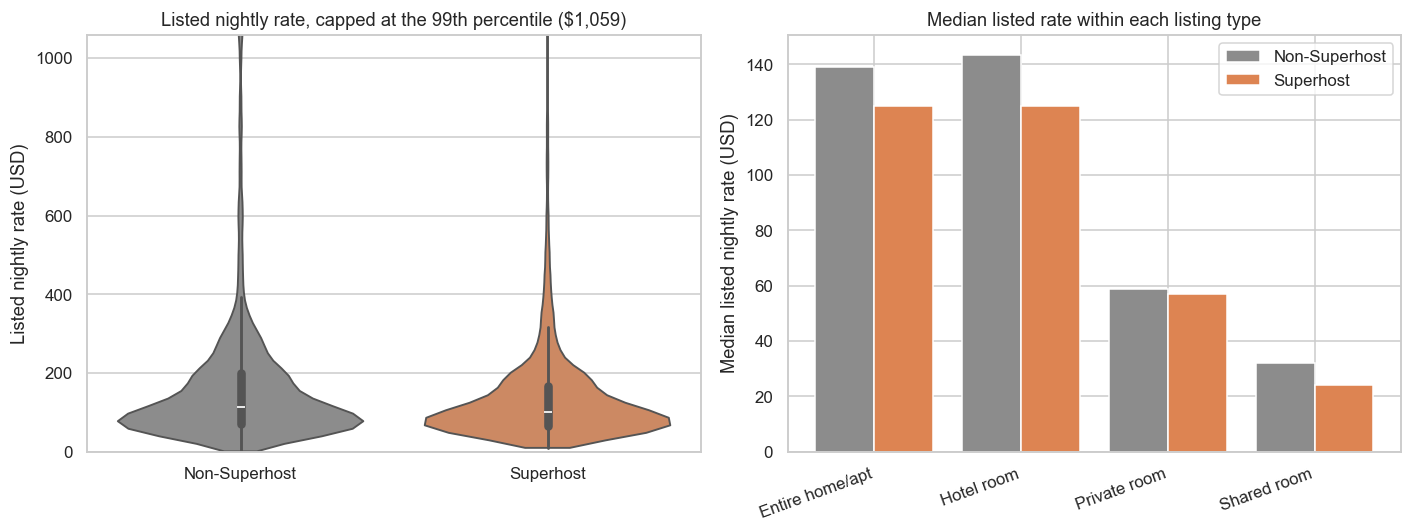

In [16]:
# Q13: do Superhosts price differently? `Nightly Rate` is the price the host sets and has no
# nulls, so all 48,711 rows are used.
print('Rows used: {:,} of {:,} (Nightly Rate has no nulls)'.format(
    int(df['Nightly Rate'].notna().sum()), len(df)))
print()

# Summary statistics for each group
grp = df.groupby('Superhost status')['Nightly Rate']
summary = pd.DataFrame({'Count': grp.count(), 'Mean': grp.mean(), 'Median': grp.median(),
                        'Std dev': grp.std(), 'Q1': grp.quantile(0.25), 'Q3': grp.quantile(0.75)})
print('Listed nightly rate by Superhost status')
print(summary.round(2).to_string())
print()

# Split the groups so the gap can be stated directly
sh = df.loc[df['Superhost'] == 1, 'Nightly Rate']
non = df.loc[df['Superhost'] == 0, 'Nightly Rate']
print('Median difference (Superhost minus non-Superhost): ${:+,.2f} ({:+.1%})'.format(
    sh.median() - non.median(), sh.median() / non.median() - 1))
print('Mean difference  (Superhost minus non-Superhost): ${:+,.2f} ({:+.1%})'.format(
    sh.mean() - non.mean(), sh.mean() / non.mean() - 1))
print()

# Within each listing type, to check the gap is not just a difference in what
# each group happens to list
by_type = df.pivot_table(index='Listing Type', columns='Superhost status',
                         values='Nightly Rate', aggfunc='median')
by_type['Difference'] = by_type['Superhost'] - by_type['Non-Superhost']
by_type['Rows'] = df.groupby('Listing Type').size()
print('Median listed rate within each listing type')
print(by_type.round(2).to_string())

# Cap the violin at the 99th percentile so the mid-market band stays readable
cap = df['Nightly Rate'].quantile(0.99)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.violinplot(data=df, x='Superhost status', y='Nightly Rate',
               order=['Non-Superhost', 'Superhost'], hue='Superhost status',
               hue_order=['Non-Superhost', 'Superhost'], palette=['#8C8C8C', '#DD8452'],
               legend=False, cut=0, ax=axes[0])
axes[0].set_ylim(0, cap)
axes[0].set_xlabel(''); axes[0].set_ylabel('Listed nightly rate (USD)')
axes[0].set_title('Listed nightly rate, capped at the 99th percentile (${:,.0f})'.format(cap))
# Second panel: median rate per listing type, the two groups side by side
types = by_type.index.tolist()
x = np.arange(len(types))
axes[1].bar(x - 0.2, by_type['Non-Superhost'], width=0.4, color='#8C8C8C', label='Non-Superhost')
axes[1].bar(x + 0.2, by_type['Superhost'], width=0.4, color='#DD8452', label='Superhost')
axes[1].set_xticks(x); axes[1].set_xticklabels(types, rotation=20, ha='right')
axes[1].set_ylabel('Median listed nightly rate (USD)')
axes[1].set_title('Median listed rate within each listing type')
axes[1].legend()
plt.tight_layout()
plt.show()

### Findings — Question 13

Superhosts list lower, not higher. The median Superhost nightly rate is $100.00 against $112.50 for
non-Superhosts, which is $12.50 or 11.1% below. This is the opposite of what most people expect
from a quality badge, so it is worth stating plainly.

The mean tells a more extreme version of the same story, $139.34 against $165.83, a gap of $26.49
or 16.0%. The mean gap is twice the median gap because the expensive tail found in Question 1 sits
mostly on the non-Superhost side, which is visible in the violin plot as a longer upper body. The
median is the honest headline and the mean overstates the difference.

It is not a composition effect. The gap survives inside all four listing types: entire homes are
$14.00 lower, hotel rooms $18.50 lower, shared rooms $8.00 lower and private rooms $1.75 lower.
Since an entire home and a private room compete in different price bands, the fact that the
direction holds within each type rules out the explanation that Superhosts simply list cheaper
kinds of property.

The violin plot also shows the two groups have a similar shape rather than a different one. Both
cluster in the same mid market band below $200, and the Superhost distribution is shifted down
rather than being narrower or more disciplined.

Superhosts are not converting the badge into pricing power, which costs both the host and Airbnb,
since the platform earns a percentage of booking value. The obvious action is rate guidance aimed
at newly awarded Superhosts. The serious caveat is direction of causation: Superhosts may be priced
low precisely because pricing low is how they earned the badge, by filling their calendars and
collecting reviews. If that is true then raising their rates trades away the occupancy that earned
it, so this needs testing on a small group before any wider rollout.

---
# Question 14 — Five-star reviews and revenue

> What does the number of 5-star reviews tell you about its impact on revenue generation? Choose a
> suitable visualization method to analyze this relationship and explain your insights.

Approach: a scatter with a binned mean line for the raw relationship, and box plots of revenue
across quintile bands of the five-star count beside it, since the count is discrete and heavily
skewed so bands read better than a scatter alone. We also look at prop_5_StarReviews_pastYear,
the proportion, because a property with 100 reviews of which 60 are five-star is a different story
from one with 60 reviews that are all five-star.

Rows used: 26,686 of 48,711 (22,025 dropped for a null on any column used)

5-star COUNT       vs revenue:  Pearson +0.083   Spearman +0.224
5-star PROPORTION  vs revenue:  Pearson +0.073   Spearman +0.030

5-star count vs total review count: Pearson +0.9909

Quintile cut points on the 5-star count: [0, 10, 26, 69, 172, 2616]
Revenue by quintile of 5-star review count
             rows  median_5star  median_revenue  median_booked_days  median_rating
band                                                                              
Q1 (fewest)  5522           4.0          1324.5                15.0           5.00
Q2           5233          17.0          1655.0                20.0           4.87
Q3           5461          42.0          2031.0                24.0           4.86
Q4           5185         122.0          2277.0                24.0           4.81
Q5 (most)    5285         481.0          2812.0                29.0           4.76


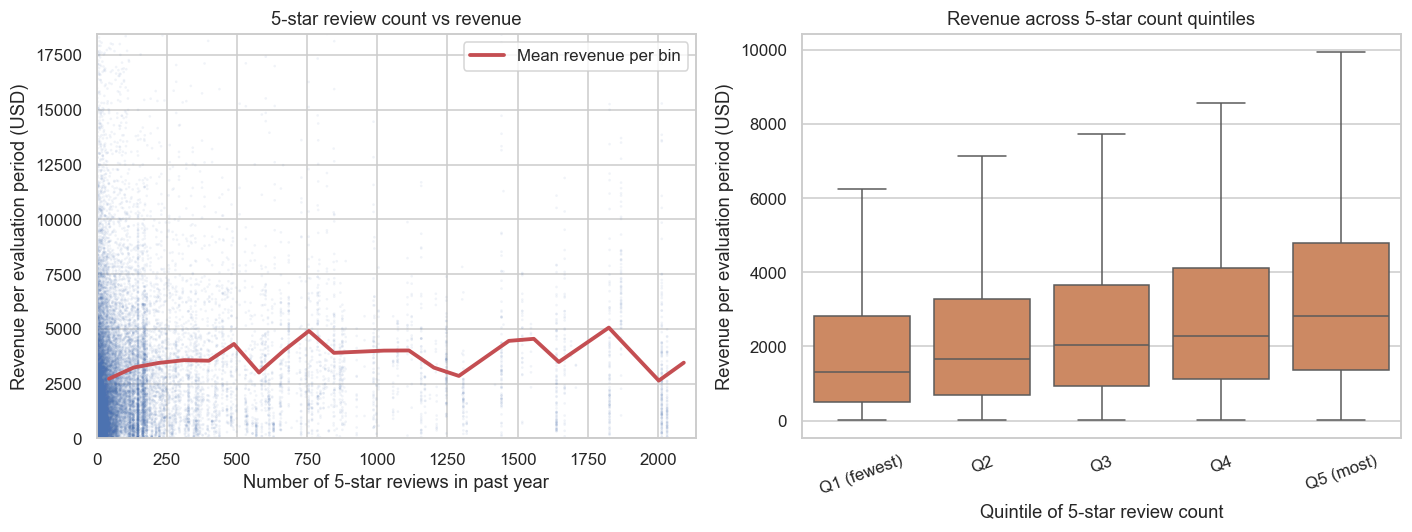

In [17]:
# Q14: does the number of 5-star reviews go with higher revenue?
q14 = df.dropna(subset=['num_5_star_Rev_pastYear', 'prop_5_StarReviews_pastYear',
                        'revenue', 'numReviews_pastYear']).copy()
print('Rows used: {:,} of {:,} ({:,} dropped for a null on any column used)'.format(
    len(q14), len(df), len(df) - len(q14)))
print()

# Count and proportion separately, because they answer different questions
for col, label in [('num_5_star_Rev_pastYear', '5-star COUNT'),
                   ('prop_5_StarReviews_pastYear', '5-star PROPORTION')]:
    pe = stats.pearsonr(q14[col], q14['revenue'])[0]
    sp = stats.spearmanr(q14[col], q14['revenue'])[0]
    print('{:<18} vs revenue:  Pearson {:+.3f}   Spearman {:+.3f}'.format(label, pe, sp))
print()
# The count is close to a rescaled review count, which is the key to reading the result.
print('5-star count vs total review count: Pearson {:+.4f}'.format(
    stats.pearsonr(q14['num_5_star_Rev_pastYear'], q14['numReviews_pastYear'])[0]))
print()

# Quintiles, since the raw count is discrete and heavily skewed
q14['band'] = pd.qcut(q14['num_5_star_Rev_pastYear'], 5,
                      labels=['Q1 (fewest)', 'Q2', 'Q3', 'Q4', 'Q5 (most)'])
print('Quintile cut points on the 5-star count:',
      [int(v) for v in q14['num_5_star_Rev_pastYear'].quantile([0, .2, .4, .6, .8, 1])])
band_tbl = q14.groupby('band', observed=True).agg(
    rows=('revenue', 'size'), median_5star=('num_5_star_Rev_pastYear', 'median'),
    median_revenue=('revenue', 'median'), median_booked_days=('booked_days', 'median'),
    median_rating=('rating_ave_pastYear', 'median'))
print('Revenue by quintile of 5-star review count')
print(band_tbl.round(2).to_string())

# Left panel the raw relationship, right panel the same data grouped into bands
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
xcap = q14['num_5_star_Rev_pastYear'].quantile(0.99)
axes[0].scatter(q14['num_5_star_Rev_pastYear'], q14['revenue'], s=3, alpha=0.08,
                color='#4C72B0', edgecolors='none')
# Binned mean line, drawn only where a bin holds 30+ rows
edges = np.linspace(0, xcap, 25)
mids, means = [], []
for lo, hi in zip(edges[:-1], edges[1:]):
    s = q14.loc[q14['num_5_star_Rev_pastYear'].between(lo, hi), 'revenue']
    if len(s) >= 30:
        mids.append((lo + hi) / 2); means.append(s.mean())
axes[0].plot(mids, means, color='#C44E52', lw=2.5, label='Mean revenue per bin')
axes[0].set_xlim(0, xcap); axes[0].set_ylim(0, q14['revenue'].quantile(0.99))
axes[0].set_xlabel('Number of 5-star reviews in past year')
axes[0].set_ylabel('Revenue per evaluation period (USD)')
axes[0].set_title('5-star review count vs revenue')
axes[0].legend()
# Outliers hidden so the boxes themselves are readable
sns.boxplot(data=q14, x='band', y='revenue', color='#DD8452', showfliers=False, ax=axes[1])
axes[1].set_xlabel('Quintile of 5-star review count')
axes[1].set_ylabel('Revenue per evaluation period (USD)')
axes[1].set_title('Revenue across 5-star count quintiles')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

### Findings — Question 14

The number of five star reviews has almost no direct relationship with revenue. The count
correlates with revenue at Pearson +0.083 and Spearman +0.224, and the proportion of reviews that
are five star correlates at +0.073 and +0.030. None of these is strong enough to treat as a driver
of revenue.

The reason the count looks like it matters is that it is essentially a review counter. It
correlates with the total number of reviews at Pearson +0.9909, so the two are very nearly the
same variable. Any apparent effect of five star reviews is mostly the effect of having been booked
and reviewed a lot, which is a record of past bookings rather than a cause of future ones.

The quintile table makes that concrete. Median revenue rises from $1,325 in the lowest five star
quintile to $2,812 in the highest, but median booked days rises alongside it from 15 nights to 29.
The listings with more five star reviews are the listings that sold more nights, which is what
generated both the reviews and the revenue.

Median rating moves the other way across the same quintiles, falling from 5.00 to 4.76. Listings
with the most five star reviews are not the best rated listings, which is the same pattern
Questions 9 and 11 found from different angles.

A host should not treat five star review count as a target, because it records nights already sold
rather than generating future ones. The proportion of five star reviews is the more meaningful of
the two, since it removes the volume effect, but on this data it is also close to zero against
revenue. The decomposition points somewhere more useful: the revenue difference across these
quintiles is nights booked, so availability, calendar management and converting inquiries into
bookings are where the revenue actually sits.

---
# Question 15 — Story of place

> Use maps or neighborhood-level data to tell a "story of place". What role does location play in
> pricing or bookings, and how would you present that insight to Airbnb management?

Approach: a latitude and longitude scatter of the listings, colored once by nightly rate and once
by occupancy rate. Putting the two side by side is the story, because if location mattered equally
to both then the two maps would look alike. No external map tiles are used, so the notebook still
exports cleanly to PDF. A neighborhood table underneath puts numbers on what the colors show.

Rows used for the maps: 48,711 of 48,711 (31,850 also have an occupancy rate)
Color scales capped at the 95th percentile: $400 a night, 0.57 occupancy


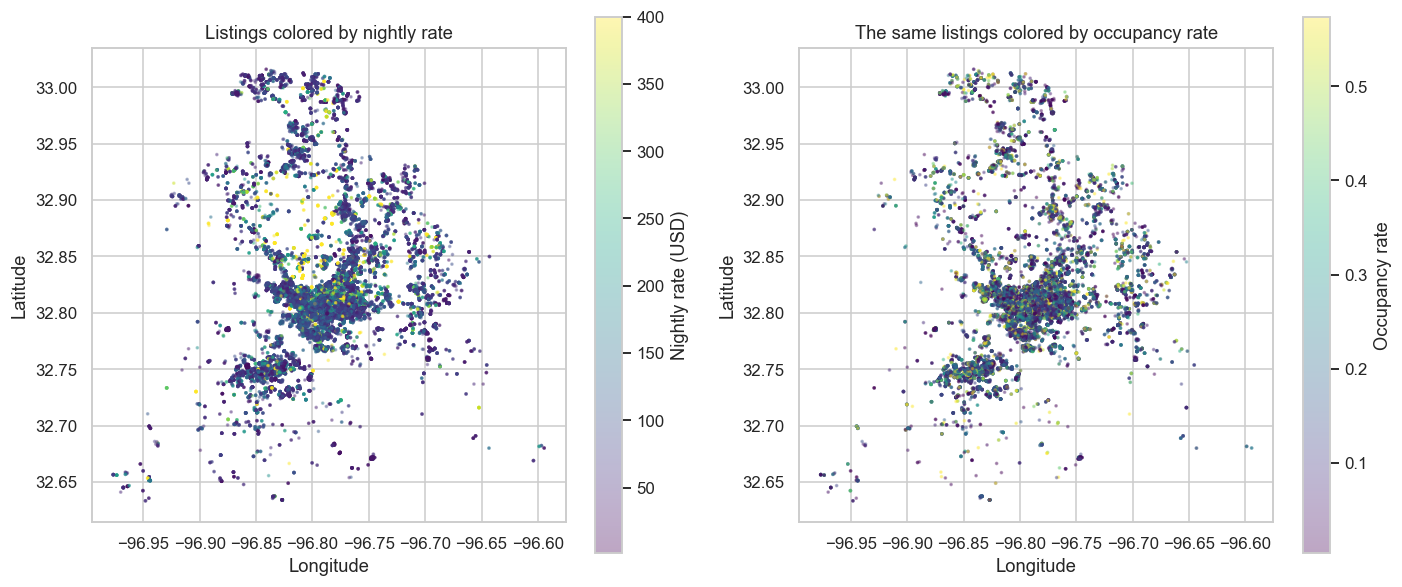


Neighborhoods with at least 30 distinct listings, sorted by median revenue
                                                                     listings  median_rate  median_occupancy  median_revenue  superhost_pct
Neighborhood                                                                                                                               
Central Dallas                                                           4914      132.000             0.163          2490.0           29.8
Lakewood                                                                   45      119.000             0.170          2069.0           45.5
Hillside/University Meadows/Ridge Wood Park/North Stonewall Terrace        40       91.000             0.181          2026.0           37.2
Oak Lawn                                                                  827      105.000             0.161          1971.0           35.1
Northwest Dallas                                                          438       

In [18]:
# Q15: what does location explain, price or bookings?
geo = df.dropna(subset=['Latitude', 'Longitude', 'Nightly Rate'])
occ = geo.dropna(subset=['occupancy_rate'])
# Cap the color scales, or a few very expensive listings wash out every other color
rate_cap = geo['Nightly Rate'].quantile(0.95)
occ_cap = occ['occupancy_rate'].quantile(0.95)
print('Rows used for the maps: {:,} of {:,} ({:,} also have an occupancy rate)'.format(
    len(geo), len(df), len(occ)))
print('Color scales capped at the 95th percentile: ${:,.0f} a night, {:.2f} occupancy'.format(
    rate_cap, occ_cap))

# Two maps of the same listings. If location mattered to both measures equally,
# the two panels would look alike
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
s1 = axes[0].scatter(geo['Longitude'], geo['Latitude'],
                     c=geo['Nightly Rate'].clip(upper=rate_cap), s=2, alpha=0.35, cmap='viridis')
axes[0].set_title('Listings colored by nightly rate')
fig.colorbar(s1, ax=axes[0], label='Nightly rate (USD)')
s2 = axes[1].scatter(occ['Longitude'], occ['Latitude'],
                     c=occ['occupancy_rate'].clip(upper=occ_cap), s=2, alpha=0.35, cmap='viridis')
axes[1].set_title('The same listings colored by occupancy rate')
fig.colorbar(s2, ax=axes[1], label='Occupancy rate')
# Equal aspect so the city is not stretched, and no map tiles so the PDF export works
for ax in axes:
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude'); ax.set_aspect('equal')
plt.tight_layout()
plt.show()

# Neighborhood-level numbers behind the maps
nb_tbl = df.dropna(subset=['Neighborhood']).groupby('Neighborhood').agg(
    listings=('Airbnb Property ID', 'nunique'), median_rate=('Nightly Rate', 'median'),
    median_occupancy=('occupancy_rate', 'median'), median_revenue=('revenue', 'median'),
    superhost_pct=('Superhost', 'mean'))
nb_tbl['superhost_pct'] = (100 * nb_tbl['superhost_pct']).round(1)
nb_tbl = nb_tbl[nb_tbl['listings'] >= 30].sort_values('median_revenue', ascending=False)
print()
print('Neighborhoods with at least 30 distinct listings, sorted by median revenue')
print(nb_tbl.round(3).to_string())
print()
# The two spreads are the comparison the whole answer rests on
print('Median nightly rate spans ${:,.0f} to ${:,.0f} ({:.2f}x)'.format(
    nb_tbl['median_rate'].min(), nb_tbl['median_rate'].max(),
    nb_tbl['median_rate'].max() / nb_tbl['median_rate'].min()))
print('Median occupancy spans {:.3f} to {:.3f} ({:.2f}x)'.format(
    nb_tbl['median_occupancy'].min(), nb_tbl['median_occupancy'].max(),
    nb_tbl['median_occupancy'].max() / nb_tbl['median_occupancy'].min()))

### Findings — Question 15

Location sets what a night is worth. It does not set whether the night sells. That contrast is the
whole story of place here, and the two maps show it directly.

The map colored by nightly rate has clear structure. Prices are highest in the downtown and Uptown
core and along the north central corridor, and they fade with distance from those areas. Across
neighborhoods with at least 30 listings, the median nightly rate runs from $50 in South Central
Dallas to $132 in Central Dallas, a spread of 2.64x.

The map colored by occupancy rate has almost no structure to describe. The colors are scattered
with no visible center, and the neighborhood numbers confirm it: median occupancy spans only 0.131
to 0.181, a spread of 1.38x, and most neighborhoods sit between 0.14 and 0.17. Guests are not
noticeably more likely to book a listing because of where it is, but they pay considerably more
for it.

Median revenue follows price rather than occupancy, running from $1,104 in North Central Dallas to
$2,490 in Central Dallas. Since revenue is nights times price and only the price half has a
geography, that is what we would expect.

Presented to Airbnb management, the headline is that location is a pricing variable and not a
demand variable in Dallas. Rate guidance should be calibrated by neighborhood, since the same
listing is worth materially more downtown, while campaigns aimed at lifting occupancy in particular
neighborhoods have much less room to work, because occupancy is already close to uniform across the
city. The caution is that neighborhood is chosen rather than assigned, so these comparisons reflect
what is listed in each place as much as the place itself.

---
# Question 16 — Recommendation to Airbnb management

> Suppose you are on Airbnb's management team. Based on your data exploration, propose one change
> (e.g., Superhost assignment criteria, pricing strategy, or neighborhood marketing). Support your
> recommendation with evidence from the dataset by justifying a KPI (e.g., revenue, occupancy,
> reviews, or location patterns), and briefly explain the trade-offs Airbnb should consider.

Approach: this is a writing question, so the cell below computes only the numbers our
recommendation quotes. We look at how revenue and realized nightly rate move across occupancy
quintiles for entire homes, holding listing type constant so the comparison is like for like.

Rows used: 24,686 entire-home property-periods that booked (6,078 properties)

Entire homes by occupancy quintile
              rows  median_occupancy  median_revenue  median_realized_rate
occ_quintile                                                              
Q1 (lowest)   4938              0.03           651.5                125.00
Q2            4944              0.10          1937.0                116.50
Q3            4931              0.16          3091.0                110.12
Q4            4939              0.24          4015.0                103.00
Q5 (highest)  4934              0.42          3743.0                101.07

Q4 to Q5: occupancy 0.240 to 0.418 (1.74x more occupied)
          median revenue $4,015 to $3,743 (-6.8%)
          median realized rate $103.00 to $101.07 (-1.9%)

Superhost share of the top occupancy quintile: 39.2% (all entire homes: 38.1%)


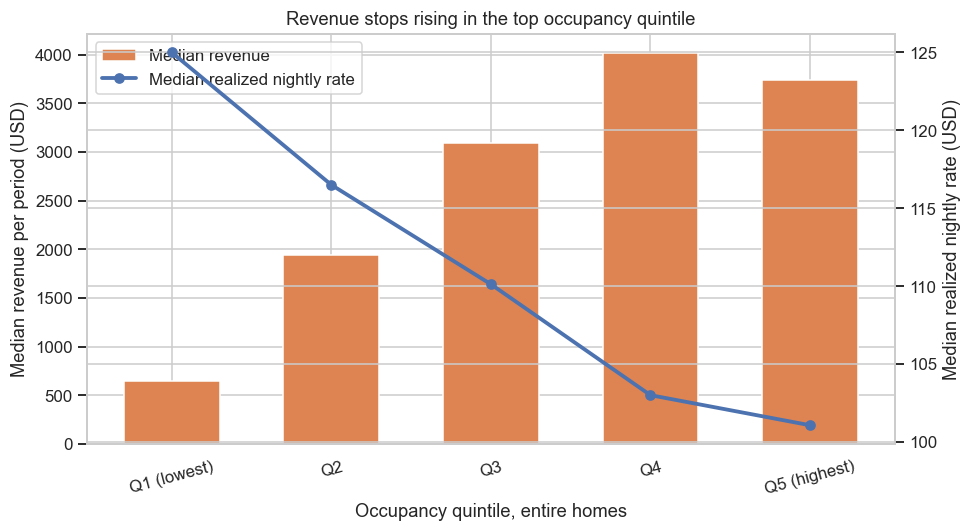

In [19]:
# Q16: the evidence behind our recommendation. Entire homes that actually booked,
# cut into quintiles of occupancy_rate.
q16 = df[df['Listing Type'] == 'Entire home/apt'].dropna(
    subset=['occupancy_rate', 'revenue', 'booked_days_avePrice']).copy()
print('Rows used: {:,} entire-home property-periods that booked ({:,} properties)'.format(
    len(q16), q16['Airbnb Property ID'].nunique()))
print()

# Five equal-sized groups ordered by occupancy, emptiest to busiest
q16['occ_quintile'] = pd.qcut(q16['occupancy_rate'], 5,
                              labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (highest)'])
tbl = q16.groupby('occ_quintile', observed=True).agg(
    rows=('revenue', 'size'), median_occupancy=('occupancy_rate', 'median'),
    median_revenue=('revenue', 'median'), median_realized_rate=('booked_days_avePrice', 'median'))
print('Entire homes by occupancy quintile')
print(tbl.round(2).to_string())
print()

# The turn between the fourth and fifth quintile is the evidence for the recommendation
q4, q5 = tbl.loc['Q4'], tbl.loc['Q5 (highest)']
print('Q4 to Q5: occupancy {:.3f} to {:.3f} ({:.2f}x more occupied)'.format(
    q4['median_occupancy'], q5['median_occupancy'],
    q5['median_occupancy'] / q4['median_occupancy']))
print('          median revenue ${:,.0f} to ${:,.0f} ({:+.1f}%)'.format(
    q4['median_revenue'], q5['median_revenue'],
    100 * (q5['median_revenue'] / q4['median_revenue'] - 1)))
print('          median realized rate ${:,.2f} to ${:,.2f} ({:+.1f}%)'.format(
    q4['median_realized_rate'], q5['median_realized_rate'],
    100 * (q5['median_realized_rate'] / q4['median_realized_rate'] - 1)))
print()
# Falsification check: if this were Superhost behavior, the top quintile would be
# far more Superhost than the base
print('Superhost share of the top occupancy quintile: {:.1%} (all entire homes: {:.1%})'.format(
    q16.loc[q16['occ_quintile'] == 'Q5 (highest)', 'Superhost'].mean(), q16['Superhost'].mean()))

# Revenue as bars and realized nightly rate as a line, so both trends read at once
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(tbl))
ax.bar(x, tbl['median_revenue'], color='#DD8452', width=0.6, label='Median revenue')
ax.set_xticks(x); ax.set_xticklabels(tbl.index, rotation=15)
ax.set_ylabel('Median revenue per period (USD)')
ax.set_xlabel('Occupancy quintile, entire homes')
# Second y-axis, because dollars per period and dollars per night are different scales
ax2 = ax.twinx()
ax2.plot(x, tbl['median_realized_rate'], color='#4C72B0', marker='o', lw=2.5,
         label='Median realized nightly rate')
ax2.set_ylabel('Median realized nightly rate (USD)')
ax.set_title('Revenue stops rising in the top occupancy quintile')
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc='upper left')
plt.tight_layout()
plt.show()

### Findings — Question 16

**The proposed change.** At the end of each Superhost evaluation quarter, send a rate review
prompt to hosts of entire home listings whose occupancy landed in the top quintile for Dallas,
suggesting they raise their nightly rate. The prompt is triggered by occupancy, not by Superhost
status.

The evidence is the turn in the top quintile. Across 24,686 entire home property periods that
booked, median revenue rises through the first four occupancy quintiles, $652, $1,937, $3,091 and
$4,015, and then falls to $3,743 in the fifth. The top quintile listings are 1.74 times as
occupied as the fourth, at 0.418 against 0.240, and yet they earn 6.8% less. At the same time the
median realized nightly rate falls at every step, from $125.00 in the lowest quintile to $101.07
in the highest. The busiest listings in Dallas are the cheapest per night, and filling more nights
has stopped adding revenue for them.

The KPI is the median realized nightly rate of the targeted group, currently $101.07, measured
against the $103.00 achieved by the fourth quintile. Realized rate is the right measure rather
than the listed rate, because it is what guests actually paid. Revenue and occupancy are the
guardrails: if cohort revenue falls below its current $3,743 median, or occupancy drops out of the
top quintile, the rate step is being funded by lost bookings and the prompt should be withdrawn.

The trigger is deliberately not the badge. Superhosts are 39.2% of the top occupancy quintile
against 38.1% of all entire homes that booked, a difference of about one percentage point, so this
is not Superhost behavior and gating it on the badge would miss most of the affected listings.

The trade-offs are real. The analysis shows the pricing headroom is unclaimed, not that it is
available, and those are different claims. These hosts may be highly occupied precisely because
they price low, in which case raising rates trades away the bookings that got them there and
lowers revenue rather than raising it. The prompt also targets the best performing supply in the
city, so a wrong recommendation costs host trust as well as bookings. This is cross sectional
evidence from self selected listings with no controls for property quality, amenities or
neighborhood, and Question 15 showed neighborhood alone moves Dallas prices by 2.64x. It should
run as a test in one or two neighborhoods against a holdout group before any wider rollout.